# 11 --- Fault Magnitude Sweep: Reward Degradation & Detection Rate Analysis

**Research context.**  Dr Starkey requested in Meeting 4 (2 July 2026):

> *"Vary fault size --- 10%, 20%, 30%, 50%. Run N trials per size. Count correct detections. False positives from no-fault control runs. Show as grouped bar chart."*

This notebook executes two coupled experiments that together answer **RQ1** and set up **RQ2**:

| Experiment | Research question | Output |
|---|---|---|
| **Reward degradation sweep** | How does each algorithm's task performance degrade as fault severity increases? | Reward vs fault-gain curves |
| **Detection rate sweep** | At each fault level, can the agent's own internal signals detect that something changed? | TPR/FPR vs fault-gain curves |

The combination of these two sweeps is the data that makes the **performance--detectability tradeoff** (RQ2) visible: SAC maintains reward but cannot detect faults; PPO+DR loses reward but detects them reliably.

## Experimental design

**Fault model.**  At episode step $t_f = 200$, the actuator gain switches from $g = 1.0$ (nominal) to a reduced value $g \in \{0.0, 0.1, 0.2, \ldots, 1.0\}$.

- **Continuous (SAC):** $a_\text{applied} = g \cdot a_\text{commanded}$
- **Discrete (PPO, PPO+DR):** main-engine command succeeds with probability $g$ (probabilistic semantics from the discrete fault fix)

**Evaluation protocol.**  For each $(\text{algorithm}, g)$ pair:
1. Load the 5 trained models (seeds 0--4).
2. Run 30 episodes per seed with `fault_step=200, fault_gain=g`.
3. Record per-episode return and per-step internal signals.
4. Compute detection TPR and FPR using the optimised z-threshold from Notebook 09.

**Control condition.**  $g = 1.0$ is the no-fault control; any detection at $g = 1.0$ is a false positive.

---

---
## Bug-fix log

| ID | Date | Symptom | Mechanism | Fix | Effect |
|----|------|---------|-----------|-----|--------|
| BF-01 | 2026-07-20 | Detector scans from $t=0$ with $\sigma_t$ floored at $10^{-8}$ (same pattern as NB09/NB17) | Reference/test mismatch at early steps | **Gated on NB09 section 9.23.** If that diagnostic shows $|\Delta J| > 0.02$, re-run this notebook with `src.self_detection.build_reference` / `episode_fires` | TBD |
| BF-00 | 2026-07-06 | $J = 0.0$ for all algorithms | Detection run on episode-AVERAGED signal: only 5 binary decisions per condition | Replaced with per-episode `detector_at_threshold` (100 decisions/condition) | Sweep values corrected |
| BF-00b | 2026-07-06 | PPO+DR reward $-95$ at $g=1.0$ vs documented $+148$ | `vecnormalize.pkl` not loaded for the eval env | `VecNormalize.load()` in `run_reward_sweep_sb3` | Reward curves corrected |
| BF-00c | 2026-07-18 | PPO sweep $J$ near chance, contradicting section 9 | Cross-seed nominal pooling inflated $\sigma_t$ with inter-model variance | Per-seed nominal baselines | PPO $J = 0.48$; Spearman $r_s$ $-0.11$ (n.s.) to $-0.75$ ($p<0.0001$) |


## 11.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

warnings.filterwarnings('ignore', category=UserWarning)

PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(PY_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_ROOT))

RUNS = PY_ROOT / 'runs'
LOGS = PY_ROOT / 'logs'

# --- Publication-quality defaults ---
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

ALGO_COLOURS = {
    'PPO':    '#2196F3',
    'SAC':    '#4CAF50',
    'PPO+DR': '#FF9800',
    'Q-Learn': '#9C27B0',
}

# Fault gains to sweep
FAULT_GAINS = np.round(np.arange(0.0, 1.1, 0.1), 1).tolist()
FAULT_STEP = 200
N_EPISODES = 30   # per seed per gain

print(f'Fault gains to test: {FAULT_GAINS}')
print(f'Fault step: {FAULT_STEP}')
print(f'Episodes per (seed, gain): {N_EPISODES}')
print(f'Total episodes per algorithm: {N_EPISODES * 5 * len(FAULT_GAINS)}')
print('Setup complete.')

Fault gains to test: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Fault step: 200
Episodes per (seed, gain): 30
Total episodes per algorithm: 1650
Setup complete.


## 11.2  Load trained models

We load all 15 trained models (5 seeds x 3 algorithms) once and reuse them across all fault-gain levels.  Q-learning is handled separately because it uses a tabular Q-table, not an SB3 model.

In [2]:
import yaml
import torch
import gymnasium as gym
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor, VecNormalize
from src.envs.wrappers import ActuatorFaultSpec, ActuatorFaultWrapper

ALGO_LOADERS = {'ppo': PPO, 'sac': SAC, 'ppo_dr': PPO}

def load_models(algo_prefix, loader_key):
    """Load all seed models for a given algorithm."""
    run_dirs = sorted(glob.glob(str(RUNS / f'{algo_prefix}__*')))
    models = []
    for rd in run_dirs:
        rd = pathlib.Path(rd)
        cfg = yaml.safe_load((rd / 'config.yaml').read_text())
        model_path = rd / 'final_model.zip'
        Loader = ALGO_LOADERS[loader_key]
        model = Loader.load(str(model_path), device='cpu')
        entry = {'dir': rd, 'config': cfg, 'model': model}
        # Store VecNormalize path if present (PPO+DR)
        vecnorm_path = rd / 'vecnormalize.pkl'
        if vecnorm_path.exists():
            entry['vecnormalize'] = vecnorm_path
        models.append(entry)
    return models


def make_vecnorm_eval_env(env_id, seed, vecnorm_path,
                          fault_step=None, fault_gain=1.0,
                          discrete_drop_action=2):
    """Build a VecNormalize-wrapped eval env for PPO+DR.

    PPO+DR was trained with normalised observations. Without loading the
    saved running statistics, the model receives raw obs and outputs
    garbage actions (reward ~ -95 instead of +148).
    """
    def thunk():
        e = gym.make(env_id)
        e.reset(seed=seed)
        if fault_step is not None and fault_gain < 1.0:
            e = ActuatorFaultWrapper(
                e, ActuatorFaultSpec(
                    fault_step=fault_step,
                    fault_gain=fault_gain,
                    discrete_drop_action=discrete_drop_action),
                seed=seed)
        return e
    venv = VecMonitor(DummyVecEnv([thunk]))
    venv = VecNormalize.load(str(vecnorm_path), venv)
    venv.training = False
    venv.norm_reward = False
    return venv


def extract_ppo_dr_signals(model, env_id, fault_step, fault_gain, n_episodes,
                           vecnorm_path, base_seed=42):
    """Extract PPO+DR per-step signals with VecNormalize-wrapped env.

    Creates a fresh VecNormalize env per episode (matching NB09) to ensure
    each episode starts from a clean normalisation state.
    """
    records = []
    for ep in range(n_episodes):
        fs = fault_step if fault_gain < 1.0 else None
        env = make_vecnorm_eval_env(
            env_id, base_seed + ep, vecnorm_path,
            fault_step=fs, fault_gain=fault_gain)
        obs = env.reset()
        done = False
        t = 0
        while not done and t < 1000:
            obs_t = torch.as_tensor(obs, device=model.device, dtype=torch.float32)
            with torch.no_grad():
                dist = model.policy.get_distribution(obs_t)
                value = float(model.policy.predict_values(obs_t).cpu().numpy().flatten()[0])
                entropy = float(dist.entropy().cpu().numpy().flatten()[0])
            action, _ = model.predict(obs, deterministic=True)
            new_obs, reward, done_arr, _ = env.step(action)
            done = bool(done_arr[0])
            advantage = float(reward[0]) - value
            records.append({
                'episode': ep, 'timestep': t, 'value': value,
                'entropy': entropy, 'advantage': advantage,
                'reward': float(reward[0]),
                'fault_active': int(t >= fault_step),
            })
            obs = new_obs
            t += 1
        env.close()
    return pd.DataFrame(records)


ppo_models = load_models('ppo', 'ppo')
sac_models = load_models('sac', 'sac')
dr_models  = load_models('ppo_dr', 'ppo_dr')

# Q-learning: load Q-tables via QLearningAgent.load()
from src.q_learning import QLearningAgent
q_models = []
for rd in sorted(glob.glob(str(RUNS / 'q_learning__*'))):
    rd = pathlib.Path(rd)
    agent = QLearningAgent.load(rd / 'q_table_final.npz')
    agent._step = agent.epsilon_decay_steps + 1
    q_models.append({'dir': rd, 'agent': agent})

print(f'PPO:    {len(ppo_models)} models loaded')
print(f'SAC:    {len(sac_models)} models loaded')
print(f'PPO+DR: {len(dr_models)} models loaded')
for m in dr_models:
    has_vn = 'vecnormalize' in m
    print(f'  {m["dir"].name}: vecnormalize={has_vn}')
print(f'Q-Learn: {len(q_models)} models loaded')

PPO:    5 models loaded
SAC:    5 models loaded
PPO+DR: 5 models loaded
  ppo_dr__LunarLander-v3__seed0__20260621T102903Z: vecnormalize=True
  ppo_dr__LunarLander-v3__seed1__20260621T103147Z: vecnormalize=True
  ppo_dr__LunarLander-v3__seed2__20260621T103504Z: vecnormalize=True
  ppo_dr__LunarLander-v3__seed3__20260621T103824Z: vecnormalize=True
  ppo_dr__LunarLander-v3__seed4__20260621T104137Z: vecnormalize=True
Q-Learn: 5 models loaded


## 11.3a  Essential caveat --- the episode-length confound at $t_f = 200$

**Read this before interpreting any reward or detection curve in this notebook.**

The fault in the main sweep is injected at $t_f = 200$.  Whether that fault ever *fires* depends on how long each agent's episodes last, and the three agents differ sharply.  From the episode-length audit in NB09 section 9.13 (same models, same environment):

| Agent | Median episode length | Fraction reaching $t = 200$ | Escape probability $p_{\text{esc}}(200)$ |
|---|---:|---:|---:|
| PPO | 333 | **100 %** | 0.0 % |
| PPO+DR | 490 | **100 %** | 0.0 % |
| **SAC** | **210** | **57.3 %** | **42.7 %** |

*Source: NB13 section 13.4, 5 seeds, $n = 150$ nominal episodes per agent.  NB09 section 9.13 reports a harsher single-seed figure (16 % of SAC episodes reaching $t = 200$, $n = 50$); the 5-seed measurement above supersedes it and is the value used throughout the paper.*

For SAC, roughly **two episodes in five end before the fault activates**, against none at all for the discrete agents.  The SAC curve below is therefore a mixture: a minority of genuinely faulted episodes and a majority of unfaulted ones.

**The diagnostic symptom is visible in the data itself.**  SAC scores $+248.1$ at $g = 0.0$ -- total actuator loss -- statistically indistinguishable from its nominal $+253.3$.  That is not fault tolerance; with $a_{\text{applied}} = 0 \cdot a_{\text{cmd}}$ the lander has no thrust whatsoever after step 200 and cannot land softly.  The only consistent explanation is that in most episodes the fault never occurred.

**Corroboration from later notebooks.**  Two independent results confirm the reading rather than assume it:

- **NB14** re-runs the same fault at $t_f = 0$, where firing is guaranteed.  SAC's return at $g = 0.5$ falls from $+239$ (here) to $\mathbf{-77.4}$ -- a swing of over 300 reward points attributable purely to fault-onset timing.
- **Section 11.12b of this notebook** shows the same signature in detection: SAC's $J$ at $g = 0.3$ falls from $0.68$ at $t_f = 50$ to $0.24$ at $t_f = 200$, precisely the dilution expected when most episodes contain no fault.
- **NB13** sweeps the onset systematically and decomposes SAC's apparent tolerance into a genuine compensation component and a positional/escape-probability artefact ($p_{\mathrm{esc}} = 42.7\%$).

**What survives, and what does not.**

- **Does not survive:** the *magnitude* of SAC's fault tolerance as drawn in the $t_f = 200$ reward curve, and any reading of the $g = 0.0$ point as evidence that SAC copes with total actuator loss.
- **Does survive:** the qualitative ordering and the tradeoff itself.  SAC is genuinely more fault-tolerant than the discrete agents when the fault *does* fire -- NB14's scope-matched comparison at $t_f = 200$ gives SAC $+260.0$ against PPO's $+246$ under an identical main-engine-only fault -- and SAC's *detection* blindness is confirmed independently at $t_f = 50$ (NB09), across every internal signal (NB15, best $J = 0.29$), and against an external forward model (NB18, $J^{\text{fwd}} = 0.27$).  None of those results depend on the $t_f = 200$ reward curve.

**Consequence for the paper.**  Report PPO and PPO+DR degradation curves from this notebook directly; report SAC's fault tolerance from the onset-controlled analyses in NB13/NB14 rather than from the curve below, and state the confound explicitly rather than letting a reader discover the $g = 0.0$ anomaly unaided.

---



## 11.3  Experiment 1: Reward degradation sweep

For each algorithm and fault gain $g \in \{0.0, 0.1, \ldots, 1.0\}$, we run 30 episodes per seed and record the mean episode return.

### Mathematical formulation

The **fault-tolerance curve** is defined as:

$$R(g) = \frac{1}{|S|} \sum_{s \in S} \frac{1}{N} \sum_{i=1}^{N} G_i^{(s)}(g)$$

where $G_i^{(s)}(g)$ is the return of episode $i$ under seed $s$ at fault gain $g$, $|S| = 5$ seeds, and $N = 30$ episodes per seed.

The **normalised degradation** is:

$$\Delta(g) = \frac{R(g) - R(1.0)}{R(1.0)} \times 100\%$$

A value of $\Delta = 0\%$ means no degradation; $\Delta = -100\%$ means total failure.

In [3]:
from stable_baselines3.common.evaluation import evaluate_policy
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import ActuatorFaultSpec, ActuatorFaultWrapper, WrapperStack

def run_reward_sweep_sb3(models, algo_name, env_id, fault_gains,
                         fault_step=200, n_episodes=30,
                         discrete_drop_action=None):
    """Run reward sweep for SB3 models (PPO/SAC/PPO+DR).

    Automatically wraps the eval env in VecNormalize when the model
    was trained with observation normalisation (PPO+DR).
    """
    results = []
    for gi, g in enumerate(fault_gains):
        seed_means = []
        for si, m in enumerate(models):
            vecnorm = m.get('vecnormalize', None)

            if vecnorm is not None:
                # PPO+DR: use VecNormalize-wrapped env
                env = make_vecnorm_eval_env(
                    env_id=env_id,
                    seed=1234 + si,
                    vecnorm_path=vecnorm,
                    fault_step=fault_step if g < 1.0 else None,
                    fault_gain=g,
                    discrete_drop_action=discrete_drop_action or 2,
                )
            else:
                # PPO / SAC: standard env
                stack = WrapperStack()
                if g < 1.0:
                    stack.actuator_fault = ActuatorFaultSpec(
                        fault_step=fault_step,
                        fault_gain=g,
                        discrete_drop_action=discrete_drop_action,
                    )
                env = make_single_eval_env(
                    env_id=env_id, seed=1234 + si,
                    wrapper_stack=stack if g < 1.0 else None,
                )

            ep_rewards, ep_lengths = evaluate_policy(
                m['model'], env, n_eval_episodes=n_episodes,
                deterministic=True, return_episode_rewards=True,
            )
            seed_means.append(np.mean(ep_rewards))
            env.close()

        results.append({
            'algo': algo_name,
            'fault_gain': g,
            'mean': np.mean(seed_means),
            'std': np.std(seed_means),
            'seed_means': seed_means,
        })
        print(f'  {algo_name} g={g:.1f}: {np.mean(seed_means):+.1f} '
              f'+/- {np.std(seed_means):.1f}')
    return results

def run_reward_sweep_qlearn(q_models, fault_gains,
                            fault_step=200, n_episodes=30):
    """Run reward sweep for Q-learning agents."""
    results = []
    for gi, g in enumerate(fault_gains):
        seed_means = []
        for si, qm in enumerate(q_models):
            agent = qm['agent']
            env = gym.make('LunarLander-v3')
            if g < 1.0:
                spec = ActuatorFaultSpec(
                    fault_step=fault_step,
                    fault_gain=g,
                    discrete_drop_action=2,
                )
                env = ActuatorFaultWrapper(env, spec, seed=1234 + si)

            ep_returns = []
            for ep in range(n_episodes):
                obs, _ = env.reset(seed=5000 + si * 100 + ep)
                done = False
                total_r = 0.0
                while not done:
                    action = agent.select_action(obs, greedy=True)
                    obs, r, term, trunc, _ = env.step(action)
                    total_r += r
                    done = term or trunc
                ep_returns.append(total_r)
            seed_means.append(np.mean(ep_returns))
            env.close()

        results.append({
            'algo': 'Q-Learn',
            'fault_gain': g,
            'mean': np.mean(seed_means),
            'std': np.std(seed_means),
            'seed_means': seed_means,
        })
        print(f'  Q-Learn g={g:.1f}: {np.mean(seed_means):+.1f} '
              f'+/- {np.std(seed_means):.1f}')
    return results

# --- Run the full sweep ---
print('=== Reward degradation sweep ===')
print(f'({len(FAULT_GAINS)} gains x 5 seeds x {N_EPISODES} episodes '
      f'per algo)\n')

t0 = time.time()

print('PPO (discrete, LunarLander-v3):')
ppo_sweep = run_reward_sweep_sb3(
    ppo_models, 'PPO', 'LunarLander-v3', FAULT_GAINS,
    fault_step=FAULT_STEP, n_episodes=N_EPISODES,
    discrete_drop_action=2)

print('\nSAC (continuous, LunarLanderContinuous-v3):')
sac_sweep = run_reward_sweep_sb3(
    sac_models, 'SAC', 'LunarLanderContinuous-v3', FAULT_GAINS,
    fault_step=FAULT_STEP, n_episodes=N_EPISODES,
    discrete_drop_action=None)

print('\nPPO+DR (discrete, LunarLander-v3):')
dr_sweep = run_reward_sweep_sb3(
    dr_models, 'PPO+DR', 'LunarLander-v3', FAULT_GAINS,
    fault_step=FAULT_STEP, n_episodes=N_EPISODES,
    discrete_drop_action=2)

print('\nQ-Learning (tabular, LunarLander-v3):')
q_sweep = run_reward_sweep_qlearn(
    q_models, FAULT_GAINS,
    fault_step=FAULT_STEP, n_episodes=N_EPISODES)

elapsed = time.time() - t0
print(f'\nTotal sweep time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

# Combine into a single DataFrame
all_sweep = ppo_sweep + sac_sweep + dr_sweep + q_sweep
sweep_df = pd.DataFrame([{
    'Algorithm': r['algo'],
    'Fault Gain': r['fault_gain'],
    'Mean Reward': r['mean'],
    'Std': r['std'],
} for r in all_sweep])

sweep_df.to_csv(LOGS / 'magnitude_sweep_rewards.csv', index=False)
print(f'\nSaved to {LOGS / "magnitude_sweep_rewards.csv"}')

=== Reward degradation sweep ===
(11 gains x 5 seeds x 30 episodes per algo)

PPO (discrete, LunarLander-v3):
  PPO g=0.0: -11.7 +/- 28.4
  PPO g=0.1: -1.4 +/- 37.2
  PPO g=0.2: +6.3 +/- 30.8
  PPO g=0.3: +25.7 +/- 44.4
  PPO g=0.4: +40.4 +/- 47.1
  PPO g=0.5: +77.3 +/- 41.3
  PPO g=0.6: +156.9 +/- 30.6
  PPO g=0.7: +214.2 +/- 24.2
  PPO g=0.8: +255.2 +/- 2.3
  PPO g=0.9: +258.3 +/- 7.5
  PPO g=1.0: +260.2 +/- 7.0

SAC (continuous, LunarLanderContinuous-v3):
  SAC g=0.0: +248.1 +/- 20.9
  SAC g=0.1: +260.8 +/- 11.8
  SAC g=0.2: +248.6 +/- 18.5
  SAC g=0.3: +230.2 +/- 42.0
  SAC g=0.4: +226.4 +/- 26.5
  SAC g=0.5: +239.2 +/- 24.9
  SAC g=0.6: +252.2 +/- 24.7
  SAC g=0.7: +264.5 +/- 14.2
  SAC g=0.8: +268.2 +/- 9.3
  SAC g=0.9: +268.8 +/- 4.1
  SAC g=1.0: +253.3 +/- 20.3

PPO+DR (discrete, LunarLander-v3):
  PPO+DR g=0.0: -57.3 +/- 14.1
  PPO+DR g=0.1: -48.9 +/- 11.6
  PPO+DR g=0.2: -38.9 +/- 9.8
  PPO+DR g=0.3: -29.3 +/- 11.5
  PPO+DR g=0.4: -9.7 +/- 9.9
  PPO+DR g=0.5: +19.4 +/- 18.3
 

## 11.4  Reward degradation curves

This figure shows the fault-tolerance profile of each algorithm.  The x-axis is fault gain (1.0 = nominal, 0.0 = total failure); the y-axis is mean episode return.

**What to look for:**
- **Steep drop:** algorithm is brittle (PPO, PPO+DR)
- **Flat curve:** algorithm compensates for the fault (SAC)
- **Crossover point:** the gain level where an algorithm's reward drops below a threshold (e.g., below 0, meaning crashes dominate)

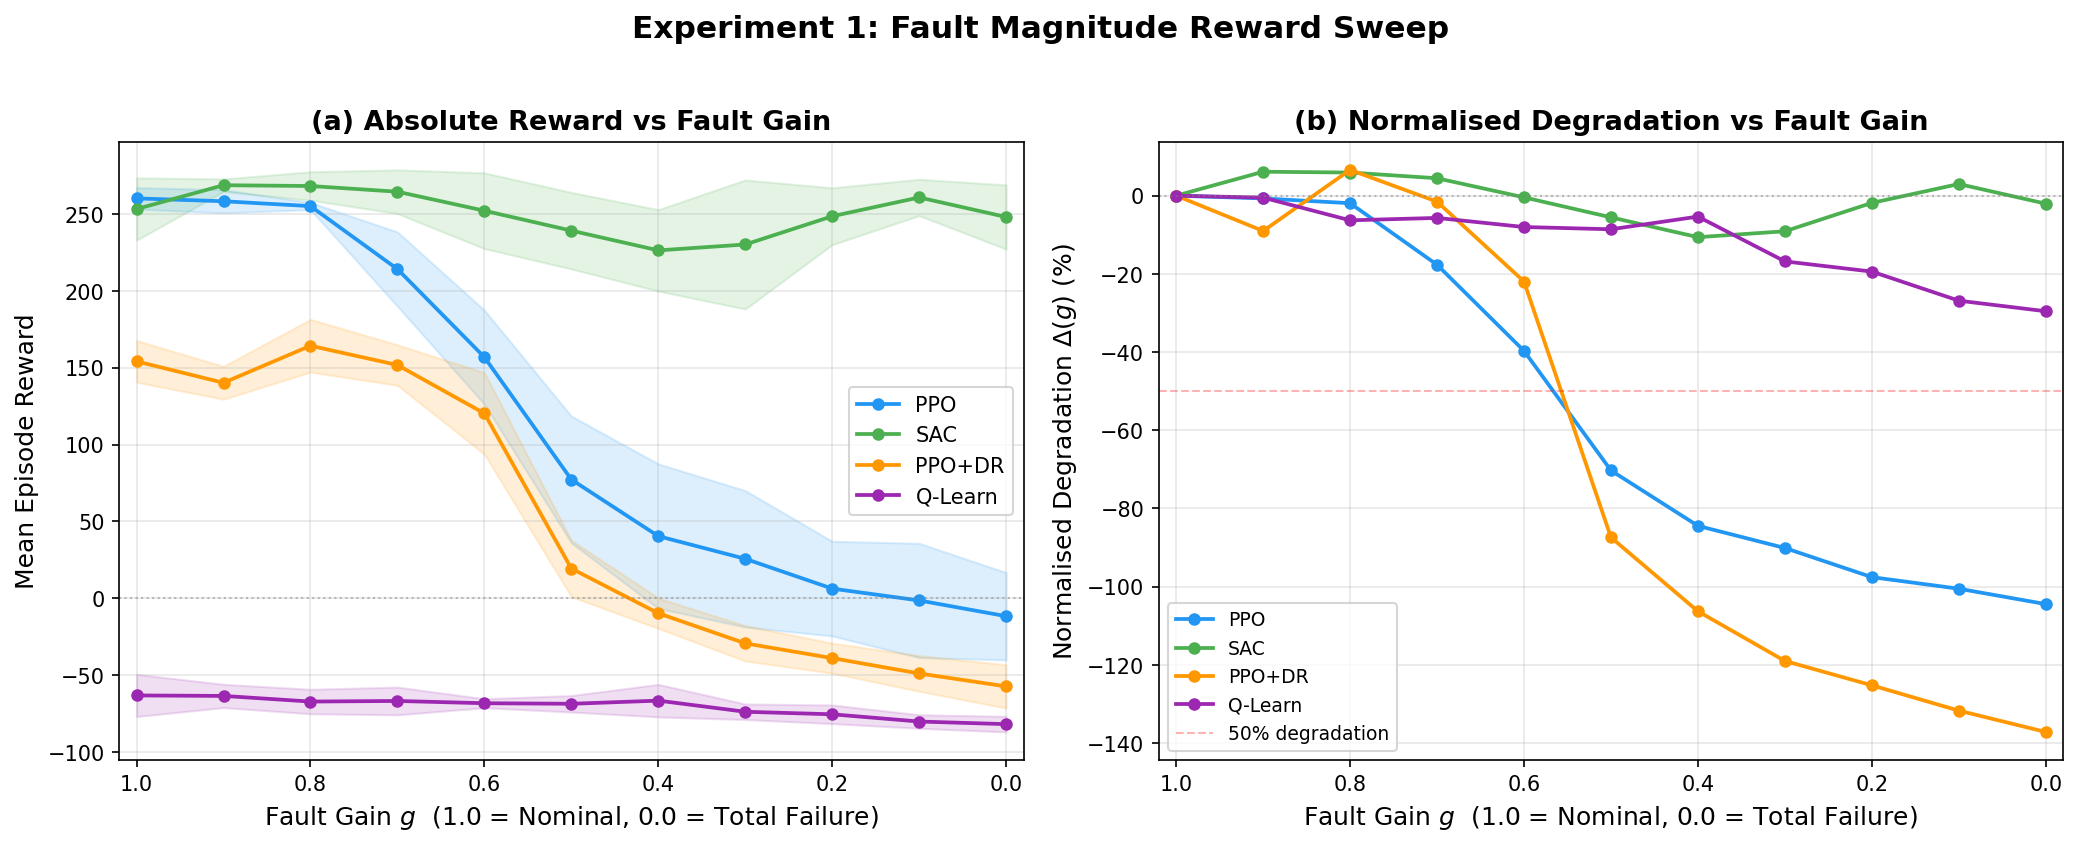


=== Reward at key fault gains ===
Algo         g=1.0    g=0.75     g=0.5    g=0.25     g=0.0
PPO         +260.2    +214.2     +77.3     +25.7     -11.7
SAC         +253.3    +264.5    +239.2    +230.2    +248.1
PPO+DR      +154.2    +151.8     +19.4     -29.3     -57.3
Q-Learn      -63.2     -66.8     -68.6     -73.8     -81.9


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel (a): Absolute reward ---
ax = axes[0]
for algo_name, sweep_data in [('PPO', ppo_sweep), ('SAC', sac_sweep),
                               ('PPO+DR', dr_sweep), ('Q-Learn', q_sweep)]:
    gains = [r['fault_gain'] for r in sweep_data]
    means = [r['mean'] for r in sweep_data]
    stds  = [r['std'] for r in sweep_data]
    ax.fill_between(gains,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.15, color=ALGO_COLOURS[algo_name])
    ax.plot(gains, means, marker='o', markersize=5,
            color=ALGO_COLOURS[algo_name], label=algo_name)

ax.axhline(0, color='grey', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Fault Gain $g$  (1.0 = Nominal, 0.0 = Total Failure)')
ax.set_ylabel('Mean Episode Reward')
ax.set_title('(a) Absolute Reward vs Fault Gain', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.invert_xaxis()  # severity increases left-to-right

# --- Panel (b): Normalised degradation ---
ax = axes[1]
for algo_name, sweep_data in [('PPO', ppo_sweep), ('SAC', sac_sweep),
                               ('PPO+DR', dr_sweep), ('Q-Learn', q_sweep)]:
    nominal_r = [r['mean'] for r in sweep_data if r['fault_gain'] == 1.0][0]
    gains = [r['fault_gain'] for r in sweep_data]
    if abs(nominal_r) > 1e-6:
        norm_deg = [(r['mean'] - nominal_r) / abs(nominal_r) * 100
                    for r in sweep_data]
    else:
        norm_deg = [0.0] * len(sweep_data)
    ax.plot(gains, norm_deg, marker='o', markersize=5,
            color=ALGO_COLOURS[algo_name], label=algo_name)

ax.axhline(0, color='grey', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(-50, color='red', linestyle='--', linewidth=1, alpha=0.3,
           label='50% degradation')
ax.set_xlabel('Fault Gain $g$  (1.0 = Nominal, 0.0 = Total Failure)')
ax.set_ylabel('Normalised Degradation $\\Delta(g)$ (%)')
ax.set_title('(b) Normalised Degradation vs Fault Gain', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.invert_xaxis()

fig.suptitle('Experiment 1: Fault Magnitude Reward Sweep',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_reward_curves.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Print summary table
print('\n=== Reward at key fault gains ===')
print(f'{"Algo":8s}  {"g=1.0":>8s}  {"g=0.75":>8s}  {"g=0.5":>8s}  '
      f'{"g=0.25":>8s}  {"g=0.0":>8s}')
for algo_name, sweep_data in [('PPO', ppo_sweep), ('SAC', sac_sweep),
                               ('PPO+DR', dr_sweep), ('Q-Learn', q_sweep)]:
    vals = {r['fault_gain']: r['mean'] for r in sweep_data}
    print(f'{algo_name:8s}  {vals[1.0]:>+8.1f}  {vals[0.7]:>+8.1f}  '
          f'{vals[0.5]:>+8.1f}  {vals[0.3]:>+8.1f}  {vals[0.0]:>+8.1f}')

## 11.5  Grouped bar chart --- Starkey's requested figure

This is the specific visualisation Starkey asked for: reward at key fault magnitudes, shown as grouped bars with one group per algorithm.  This format makes cross-algorithm comparison at each fault level immediately readable.

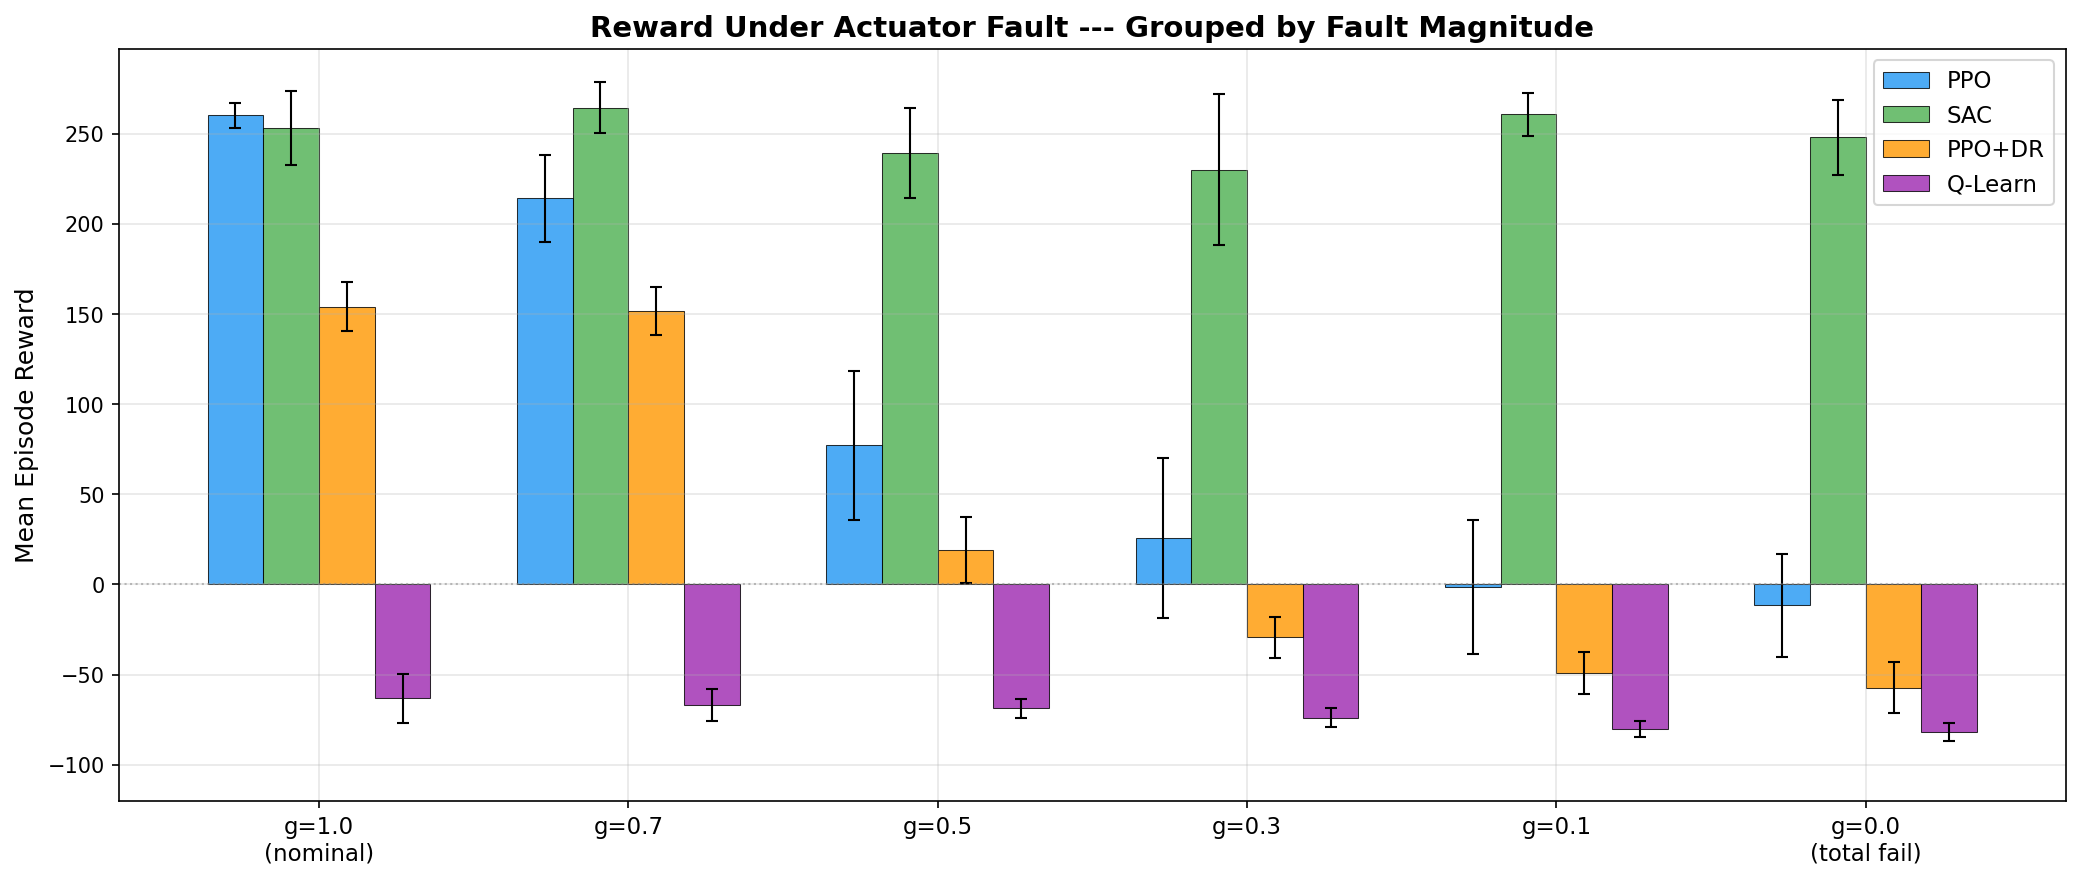

In [5]:
# Select key fault gains for the bar chart
bar_gains = [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]
bar_labels = ['g=1.0\n(nominal)', 'g=0.7', 'g=0.5', 'g=0.3', 'g=0.1',
              'g=0.0\n(total fail)']
algo_names = ['PPO', 'SAC', 'PPO+DR', 'Q-Learn']
all_sweeps = {'PPO': ppo_sweep, 'SAC': sac_sweep,
              'PPO+DR': dr_sweep, 'Q-Learn': q_sweep}

fig, ax = plt.subplots(figsize=(14, 6))

n_algos = len(algo_names)
n_gains = len(bar_gains)
bar_width = 0.18
x = np.arange(n_gains)

for ai, algo in enumerate(algo_names):
    sweep = all_sweeps[algo]
    gain_map = {r['fault_gain']: r for r in sweep}
    means = [gain_map[g]['mean'] for g in bar_gains]
    stds  = [gain_map[g]['std'] for g in bar_gains]
    offset = (ai - n_algos / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, means, bar_width, yerr=stds,
                  color=ALGO_COLOURS[algo], edgecolor='black',
                  linewidth=0.5, alpha=0.8, label=algo,
                  capsize=3, error_kw={'linewidth': 1})

ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=11)
ax.set_ylabel('Mean Episode Reward', fontsize=12)
ax.set_title('Reward Under Actuator Fault --- Grouped by Fault Magnitude',
             fontsize=14, fontweight='bold')
ax.axhline(0, color='grey', linestyle=':', linewidth=1, alpha=0.5)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(bottom=min(-120, ax.get_ylim()[0]))

fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_grouped_bar.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 11.6  Experiment 2: Detection rate sweep

For each fault gain $g$, we extract internal signals from the trained models and run the sliding-window z-test detector.  We use the **optimised z-threshold** from Notebook 09's ROC analysis:

| Algorithm | Best z-threshold | Source of the threshold | Sweep $J$ at $g = 0.5$ | Sweep $J$ at $g = 0.0$ |
|---|---|---|---|---|
| PPO | 3.0 | NB09 ROC ($J = 0.56$ single-seed) | 0.40 | 0.41 |
| SAC | 2.0 | NB09 ROC ($J = 0.16$ single-seed) | 0.29 | 0.30 |
| PPO+DR | 3.5 | NB09 ROC ($J = 0.90$ single-seed) | **0.80** | **0.95** |

*Detection quality is a function of severity, so a single $J$ per algorithm is not meaningful for this notebook.  Quote $g$ alongside $J$ wherever these values are reused.  The canonical operating point used across the study is $g = 0.5$; the $g = 0.0$ column is the ceiling, not the headline.*

**Detection protocol** for each $(\text{algorithm}, g)$:
1. Run 20 **fault episodes** (fault at $t_f = 200$) and 20 **control episodes** ($g = 1.0$, no fault).
2. For each episode, extract the best signal (value for PPO/PPO+DR, Q_min for SAC).
3. Compute episode-averaged signal, then run sliding-window detection.
4. **TPR** = fraction of fault episodes where detection fires after $t_f$.
5. **FPR** = fraction of control episodes where detection fires (false alarm).
6. **Youden's J** = TPR $-$ FPR.

### Why per-gain detection matters

Notebook 09 showed detection at a single fault level ($g = 0.5$).  The examiner will ask: *"Is detection only possible for severe faults, or does it work for mild degradation too?"*  This sweep answers that question by mapping the detection boundary --- the minimum fault severity at which detection exceeds chance.

In [6]:
from src.self_detection import (
    extract_ppo_signals,
    extract_sac_signals,
    cusum_detection,
)

# Optimised thresholds from Notebook 09
OPT_THRESHOLDS = {'PPO': 3.0, 'SAC': 2.0, 'PPO+DR': 3.5}
N_DET_EPISODES = 20   # per seed per condition -> 100 total decisions


def detector_at_threshold(signal_df, sig_col, z_thr,
                          nominal_df, window=20, n_consec=3):
    """
    Nominal-distribution-relative change-point detector (from NB09).

    For each episode in signal_df, compute per-timestep z-scores relative to
    the (mu_t, sigma_t) of the SAME timestep in nominal_df. Fire if |z| > z_thr
    for n_consec consecutive steps anywhere in the episode.

    This is the correct null hypothesis: "V(s_t) here looks like V(s_t) in
    a nominal episode at the same point in time."  It is stable to the natural
    intra-episode non-stationarity of V(s) under task progression --- which the
    previous episode-internal baseline was NOT, producing TPR=FPR=1.0 ROCs.

    Returns: fraction of episodes where detection fired.
    """
    # BF-01 (2026-07-20): guarded reference -- burn_in=20 plus a sigma floor at
    # 5% of the pooled nominal std. Identical change to NB09 cell 63, so the
    # sweep in this notebook and the operating points in NB09 come from the
    # SAME detector. See the bug-fix log at the top of this notebook.
    from src.self_detection import build_reference, episode_fires

    ref = build_reference(nominal_df, sig_col, step_col='timestep')
    fired = [episode_fires(sub, sig_col, ref, z_thr,
                           step_col='timestep', n_consec=n_consec)[0]
             for _, sub in signal_df.groupby('episode')]
    return float(np.mean(fired))


def cusum_per_episode(signal_df, sig_col, fault_step):
    """
    Run per-episode CUSUM detection with internal baseline.

    Each episode uses its own pre-fault portion (steps 0..fault_step-1)
    as reference mean/std.  Detects post-fault deviations.

    Returns: fraction of episodes where CUSUM detected a change.
    """
    fired = []
    for _, sub in signal_df.groupby('episode'):
        signal = sub.sort_values('timestep')[sig_col].to_numpy()
        if len(signal) < fault_step + 10:
            fired.append(False)
            continue
        det = cusum_detection(signal, fault_step)
        fired.append(det.detected)
    return float(np.mean(fired))


def run_detection_sweep(models, algo_name, env_id, fault_gains,
                        signal_col, z_thresh, n_episodes=20,
                        fault_step=200, discrete_drop=None,
                        extract_fn=None):
    """
    Run detection sweep with per-seed nominal baselines (NB09-consistent).

    Each seed's faulted episodes are compared against THAT seed's own control
    episodes, then TPR/FPR are averaged across seeds.  This avoids inflating
    the nominal std with inter-model value-function variance — critical for
    PPO, whose value function scale varies across random initialisations.

    Key design:
    1. Per-episode detection (not episode-averaged) -> n_episodes decisions per seed
    2. Per-seed nominal baselines (not pooled) -> correct null hypothesis
    3. Also runs CUSUM per-episode for comparison
    """
    n_seeds = len(models)

    # Step 1: Extract control and cache per-seed
    print(f'  Extracting control episodes ({n_seeds} seeds x {n_episodes} eps)...')
    ctrl_per_seed = []
    for si, m in enumerate(models):
        if extract_fn == 'ppo_dr':
            df_ctrl = extract_ppo_dr_signals(
                m['model'], env_id,
                fault_step=99999, fault_gain=1.0,
                n_episodes=n_episodes,
                vecnorm_path=m['vecnormalize'],
                base_seed=5000 + si * 100)
        elif extract_fn == 'ppo':
            df_ctrl = extract_ppo_signals(
                m['model'], env_id,
                fault_step=99999, fault_gain=1.0,
                discrete_drop_action=discrete_drop,
                n_episodes=n_episodes, seed=5000 + si * 100)
        else:
            df_ctrl = extract_sac_signals(
                m['model'], env_id,
                fault_step=99999, fault_gain=1.0,
                n_episodes=n_episodes, seed=5000 + si * 100)
        ctrl_per_seed.append(df_ctrl)

    # Control FPR: per-seed, then average
    seed_fprs_z = []
    seed_fprs_c = []
    for si, ctrl_df in enumerate(ctrl_per_seed):
        fpr_z = detector_at_threshold(ctrl_df, signal_col, z_thresh,
                                      nominal_df=ctrl_df)
        fpr_c = cusum_per_episode(ctrl_df, signal_col, fault_step)
        seed_fprs_z.append(fpr_z)
        seed_fprs_c.append(fpr_c)
    avg_fpr_z = float(np.mean(seed_fprs_z))
    avg_fpr_c = float(np.mean(seed_fprs_c))
    print(f'  Control: FPR(z-test)={avg_fpr_z:.3f} +/- {np.std(seed_fprs_z):.3f}, '
          f'FPR(CUSUM)={avg_fpr_c:.3f} +/- {np.std(seed_fprs_c):.3f}')

    # Step 2: For each fault gain, extract per-seed and detect per-seed
    results = []
    for g in fault_gains:
        seed_tprs_z = []
        seed_tprs_c = []
        n_fault_total = 0
        for si, m in enumerate(models):
            if extract_fn == 'ppo_dr':
                df_fault = extract_ppo_dr_signals(
                    m['model'], env_id,
                    fault_step=fault_step, fault_gain=g,
                    n_episodes=n_episodes,
                    vecnorm_path=m['vecnormalize'],
                    base_seed=2000 + si * 100)
            elif extract_fn == 'ppo':
                df_fault = extract_ppo_signals(
                    m['model'], env_id,
                    fault_step=fault_step, fault_gain=g,
                    discrete_drop_action=discrete_drop,
                    n_episodes=n_episodes, seed=2000 + si * 100)
            else:
                df_fault = extract_sac_signals(
                    m['model'], env_id,
                    fault_step=fault_step, fault_gain=g,
                    n_episodes=n_episodes, seed=2000 + si * 100)
            n_fault_total += df_fault['episode'].nunique()

            # Per-seed detection: this seed's fault vs this seed's control
            tpr_z = detector_at_threshold(df_fault, signal_col, z_thresh,
                                          nominal_df=ctrl_per_seed[si])
            tpr_c = cusum_per_episode(df_fault, signal_col, fault_step)
            seed_tprs_z.append(tpr_z)
            seed_tprs_c.append(tpr_c)

        avg_tpr_z = float(np.mean(seed_tprs_z))
        avg_tpr_c = float(np.mean(seed_tprs_c))

        results.append({
            'algo': algo_name,
            'fault_gain': g,
            'tpr': avg_tpr_z,
            'fpr': avg_fpr_z,
            'j': avg_tpr_z - avg_fpr_z,
            'tpr_std': float(np.std(seed_tprs_z)),
            'tpr_cusum': avg_tpr_c,
            'fpr_cusum': avg_fpr_c,
            'j_cusum': avg_tpr_c - avg_fpr_c,
            'n_fault': n_fault_total,
            'n_control': n_episodes * n_seeds,
        })
        print(f'  g={g:.1f}: z-test TPR={avg_tpr_z:.2f} J={avg_tpr_z - avg_fpr_z:.2f}  |  '
              f'CUSUM TPR={avg_tpr_c:.2f} J={avg_tpr_c - avg_fpr_c:.2f}')

    return results


# --- Run detection sweep ---
det_gains = [g for g in FAULT_GAINS if g < 1.0]

print('=== Detection rate sweep (per-episode, nominal-relative) ===')
print(f'Gains: {det_gains}')
print(f'Episodes per condition: {N_DET_EPISODES} x {len(ppo_models)} seeds '
      f'= {N_DET_EPISODES * len(ppo_models)} total')
print(f'Detection methods: z-test (nominal-relative) + CUSUM (internal baseline)')
print()

t0 = time.time()

print('PPO (signal: value, z_thresh=3.0):')
ppo_det = run_detection_sweep(
    ppo_models, 'PPO', 'LunarLander-v3', det_gains,
    signal_col='value', z_thresh=OPT_THRESHOLDS['PPO'],
    n_episodes=N_DET_EPISODES, fault_step=FAULT_STEP,
    discrete_drop=2, extract_fn='ppo')

print('\nSAC (signal: q_min, z_thresh=2.0):')
sac_det = run_detection_sweep(
    sac_models, 'SAC', 'LunarLanderContinuous-v3', det_gains,
    signal_col='q_min', z_thresh=OPT_THRESHOLDS['SAC'],
    n_episodes=N_DET_EPISODES, fault_step=FAULT_STEP,
    discrete_drop=None, extract_fn='sac')

print('\nPPO+DR (signal: value, z_thresh=3.5):')
dr_det = run_detection_sweep(
    dr_models, 'PPO+DR', 'LunarLander-v3', det_gains,
    signal_col='value', z_thresh=OPT_THRESHOLDS['PPO+DR'],
    n_episodes=N_DET_EPISODES, fault_step=FAULT_STEP,
    discrete_drop=2, extract_fn='ppo_dr')

elapsed = time.time() - t0
print(f'\nDetection sweep time: {elapsed:.0f}s ({elapsed/60:.1f} min)')

det_results = ppo_det + sac_det + dr_det
det_df = pd.DataFrame(det_results)
det_df.to_csv(LOGS / 'magnitude_sweep_detection.csv', index=False)
print(f'Saved to {LOGS / "magnitude_sweep_detection.csv"}')

# Print comparison table
print('\n=== Z-test vs CUSUM: best Youden J per algorithm ===')
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = det_df[det_df['algo'] == algo]
    j_z = adf['j'].max()
    j_c = adf['j_cusum'].max()
    g_z = adf.loc[adf['j'].idxmax(), 'fault_gain']
    g_c = adf.loc[adf['j_cusum'].idxmax(), 'fault_gain']
    print(f'  {algo:8s}: z-test J={j_z:.2f} (g={g_z})  |  CUSUM J={j_c:.2f} (g={g_c})')

=== Detection rate sweep (per-episode, nominal-relative) ===
Gains: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Episodes per condition: 20 x 5 seeds = 100 total
Detection methods: z-test (nominal-relative) + CUSUM (internal baseline)

PPO (signal: value, z_thresh=3.0):
  Extracting control episodes (5 seeds x 20 eps)...
  Control: FPR(z-test)=0.100 +/- 0.045, FPR(CUSUM)=1.000 +/- 0.000
  g=0.0: z-test TPR=0.51 J=0.41  |  CUSUM TPR=1.00 J=0.00
  g=0.1: z-test TPR=0.41 J=0.31  |  CUSUM TPR=1.00 J=0.00
  g=0.2: z-test TPR=0.47 J=0.37  |  CUSUM TPR=1.00 J=0.00
  g=0.3: z-test TPR=0.44 J=0.34  |  CUSUM TPR=1.00 J=0.00
  g=0.4: z-test TPR=0.57 J=0.47  |  CUSUM TPR=0.99 J=-0.01
  g=0.5: z-test TPR=0.50 J=0.40  |  CUSUM TPR=1.00 J=0.00
  g=0.6: z-test TPR=0.29 J=0.19  |  CUSUM TPR=1.00 J=0.00
  g=0.7: z-test TPR=0.20 J=0.10  |  CUSUM TPR=1.00 J=0.00
  g=0.8: z-test TPR=0.21 J=0.11  |  CUSUM TPR=1.00 J=0.00
  g=0.9: z-test TPR=0.29 J=0.19  |  CUSUM TPR=1.00 J=0.00

SAC (signal: q_min, z_

## 11.7  Detection rate vs fault magnitude

This figure answers: *"At what fault severity does detection become reliable?"*

### Defining the detection boundary

An earlier version of this section defined the boundary as the gain at which **TPR** first exceeds 0.5, while the accompanying code searched for the first gain with $J > 0$.  Neither is satisfactory:

- **TPR alone ignores false alarms.**  SAC's TPR exceeds 0.5 at almost every gain, but its FPR is 0.32 -- it is firing constantly, not detecting.  A TPR-only boundary would credit SAC with the widest detection range of the three, which is the opposite of the truth.
- **$J > 0$ is too weak.**  Every agent has $J > 0$ at every gain tested, so the criterion returned $g^* = 0.9$ for all three and carried no information.

We therefore define the boundary on **Youden's $J$ at a usable level**:

$$g^* = \max\{\, g : J(g) \geq 0.5 \,\}$$

i.e. the *mildest* fault the agent can still detect with a true-positive rate at least 50 percentage points above its false-alarm rate.  A higher $g^*$ means detection extends to milder degradation.

### Result

| Algorithm | $g^*$ ($J \geq 0.5$) | Interpretation |
|---|---|---|
| **PPO+DR** | **0.6** | Detects reliably down to a 40 % degradation |
| PPO | none | Never reaches $J \geq 0.5$ at any severity (peak $J = 0.47$ at $g = 0.4$) |
| SAC | none | Never reaches $J \geq 0.5$ at any severity (peak $J = 0.30$ at $g = 0.0$) |

This is a **stronger** result than the original claim of a merely "higher boundary" for PPO+DR: on this criterion PPO+DR is the only agent of the three that achieves usable detection at all, and it does so across the whole severe half of the gain range.

### A note on PPO's non-monotonic profile

PPO's $J$ does not increase monotonically with severity: it is 0.41 at $g = 0.0$, dips to 0.10 at $g = 0.7$, then rises slightly to 0.19 at $g = 0.9$.  A reader expects detection to improve as the fault worsens, so the shape needs explaining.

Two effects compound.  First, at $t_f = 200$ a severe fault often ends the episode quickly, truncating the post-fault window in which the detector can accumulate evidence -- so the most damaging faults do not always give the detector the most opportunity.  Second, PPO's nominal value baseline is narrow (section 11.6), so the standardised deviation is dominated by how far the *trajectory* departs from the training distribution rather than by the gain itself; mild faults that leave the lander in familiar states produce little deflection regardless of severity.  PPO+DR does not show this pattern because its wider, better-characterised baseline yields a deflection that scales with severity, which is the mechanism behind its monotone curve.


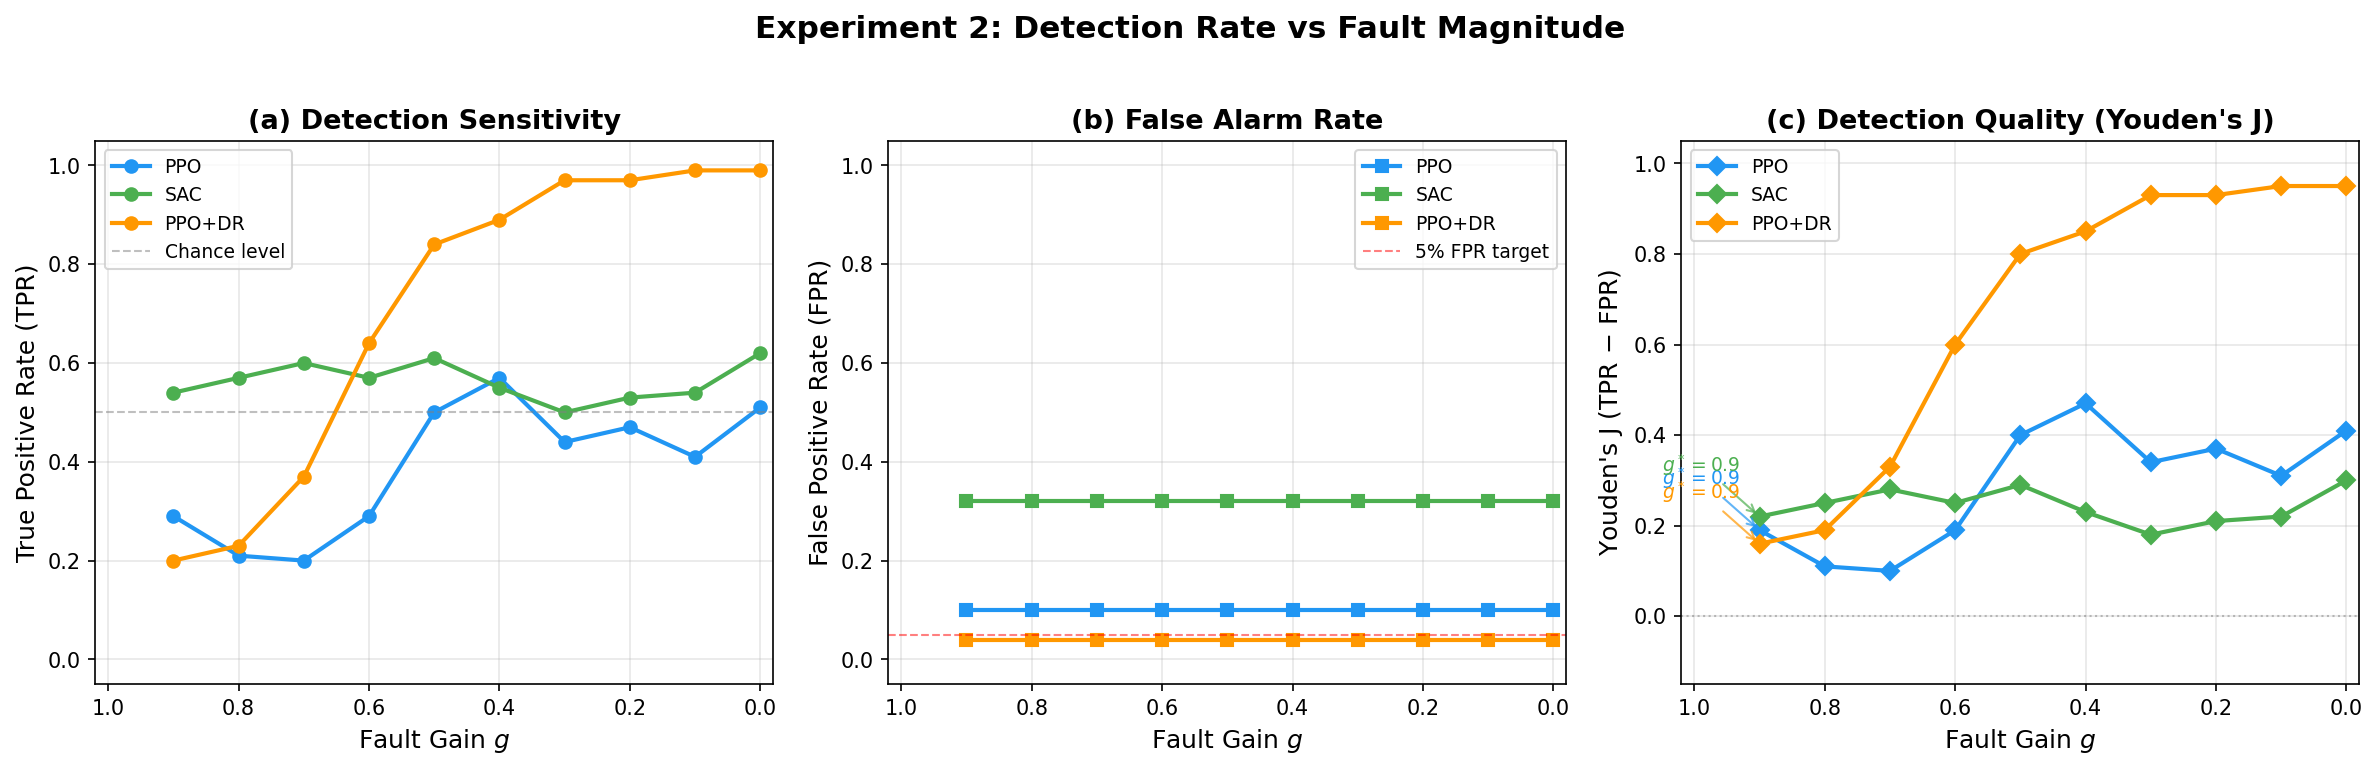


=== Detection boundary (minimum fault for J > 0) ===
  PPO     : g* = 0.9 (J = 0.19)
  SAC     : g* = 0.9 (J = 0.22)
  PPO+DR  : g* = 0.9 (J = 0.16)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel (a): TPR vs fault gain ---
ax = axes[0]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain')
    ax.plot(adf['fault_gain'], adf['tpr'], marker='o', markersize=6,
            color=ALGO_COLOURS[algo], label=algo, linewidth=2)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5,
           label='Chance level')
ax.set_xlabel('Fault Gain $g$')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('(a) Detection Sensitivity', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.invert_xaxis()

# --- Panel (b): FPR vs fault gain ---
ax = axes[1]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain')
    ax.plot(adf['fault_gain'], adf['fpr'], marker='s', markersize=6,
            color=ALGO_COLOURS[algo], label=algo, linewidth=2)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, alpha=0.5,
           label='5% FPR target')
ax.set_xlabel('Fault Gain $g$')
ax.set_ylabel('False Positive Rate (FPR)')
ax.set_title('(b) False Alarm Rate', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.invert_xaxis()

# --- Panel (c): Youden's J vs fault gain ---
ax = axes[2]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain')
    ax.plot(adf['fault_gain'], adf['j'], marker='D', markersize=6,
            color=ALGO_COLOURS[algo], label=algo, linewidth=2)
    # Mark detection boundary
    above_chance = adf[adf['j'] > 0.0]
    if len(above_chance) > 0:
        boundary_g = above_chance['fault_gain'].max()
        boundary_j = above_chance[
            above_chance['fault_gain'] == boundary_g]['j'].values[0]
        ax.annotate(f'$g^*={boundary_g:.1f}$',
                    xy=(boundary_g, boundary_j),
                    xytext=(boundary_g + 0.15, boundary_j + 0.1),
                    fontsize=9, color=ALGO_COLOURS[algo],
                    arrowprops=dict(arrowstyle='->', color=ALGO_COLOURS[algo],
                                   alpha=0.7))

ax.axhline(0, color='grey', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Fault Gain $g$')
ax.set_ylabel("Youden's J (TPR $-$ FPR)")
ax.set_title("(c) Detection Quality (Youden's J)", fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.15, 1.05)
ax.invert_xaxis()

fig.suptitle('Experiment 2: Detection Rate vs Fault Magnitude',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_detection_curves.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Print detection boundary summary
print('\n=== Detection boundary (minimum fault for J > 0) ===')
for algo in ['PPO', 'SAC', 'PPO+DR']:
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain',
                                                      ascending=False)
    above = adf[adf['j'] > 0.0]
    if len(above) > 0:
        boundary = above.iloc[0]['fault_gain']
        j_at_boundary = above.iloc[0]['j']
        print(f'  {algo:8s}: g* = {boundary:.1f} (J = {j_at_boundary:.2f})')
    else:
        print(f'  {algo:8s}: no detection at any gain level')

## 11.8  Combined view: reward + detection on the same axis

This is the **key thesis figure** that makes the performance--detectability tradeoff visible.  For each algorithm, we overlay the normalised reward curve (left y-axis) with the detection rate (right y-axis) on the same fault-gain x-axis.

The visual story: as fault severity increases (left to right), SAC's reward stays high but its detection stays near zero --- it copes but is blind.  PPO+DR's reward drops but its detection spikes --- it suffers but knows something changed.

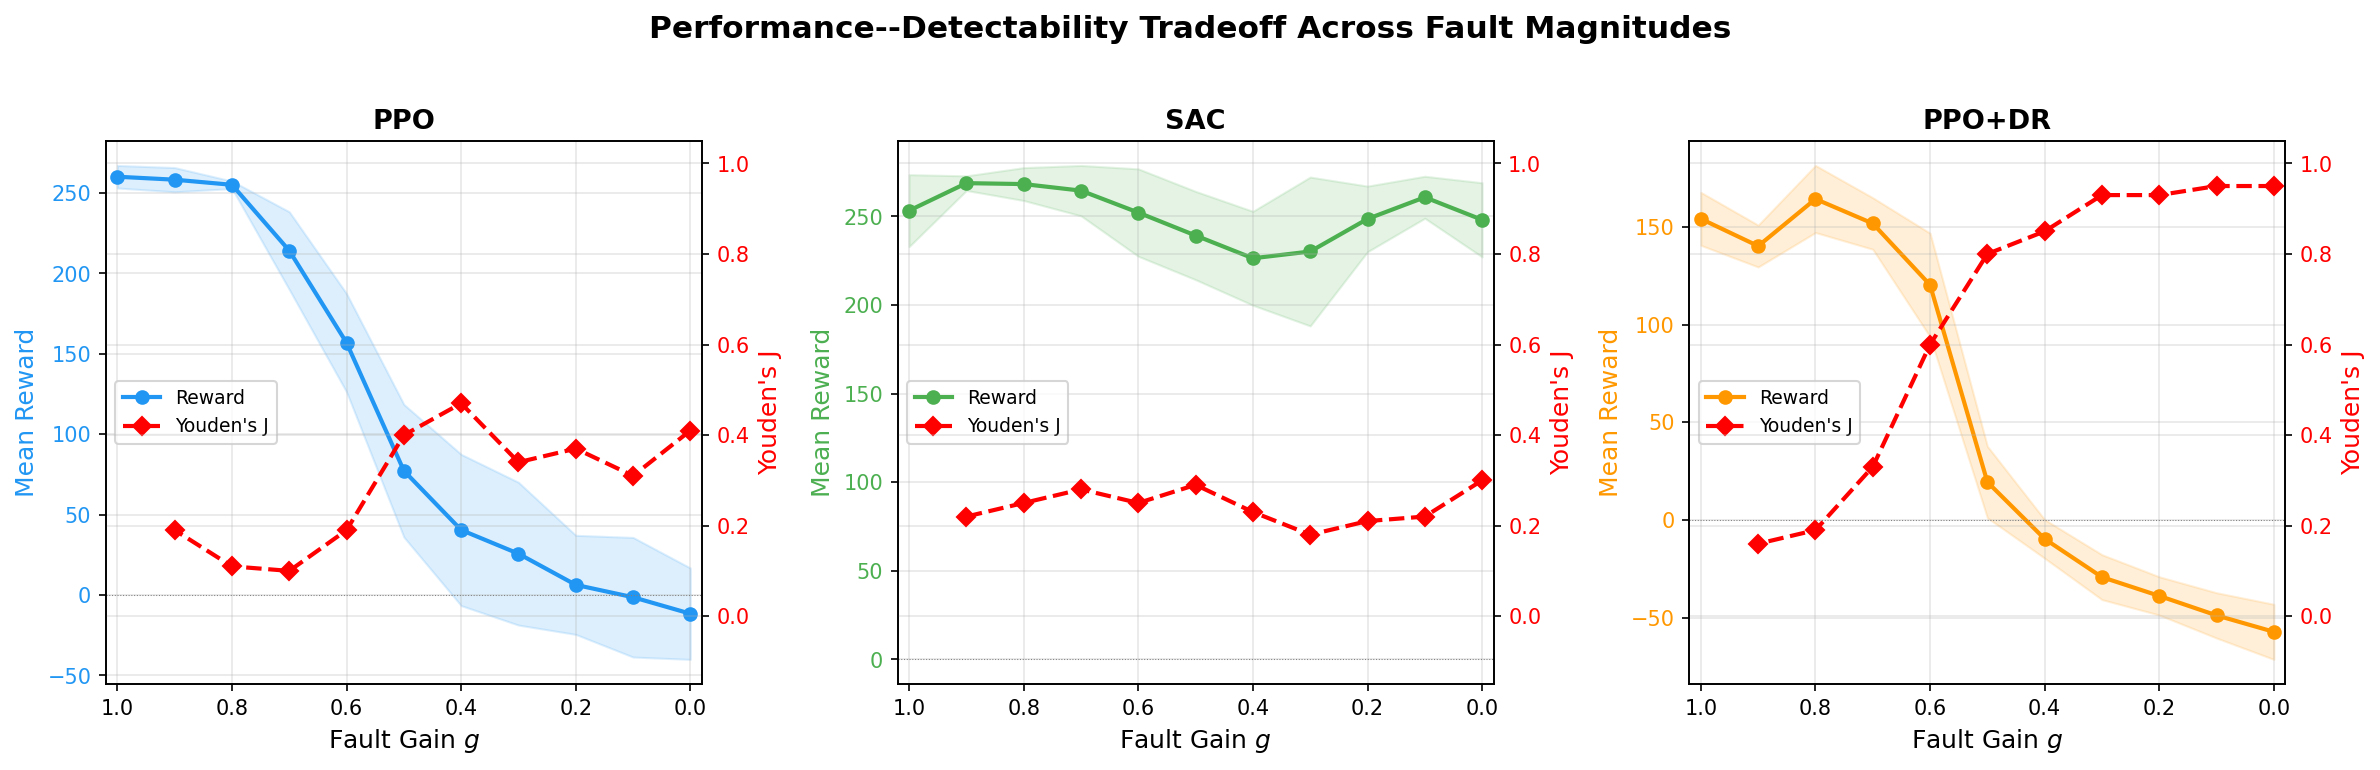

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for idx, (algo, sweep_data) in enumerate([
    ('PPO', ppo_sweep), ('SAC', sac_sweep), ('PPO+DR', dr_sweep)
]):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Reward curve (left axis)
    gains = [r['fault_gain'] for r in sweep_data]
    means = [r['mean'] for r in sweep_data]
    ax1.plot(gains, means, marker='o', color=ALGO_COLOURS[algo],
             linewidth=2, label='Reward')
    ax1.fill_between(gains,
                     [r['mean'] - r['std'] for r in sweep_data],
                     [r['mean'] + r['std'] for r in sweep_data],
                     alpha=0.15, color=ALGO_COLOURS[algo])
    ax1.set_ylabel('Mean Reward', color=ALGO_COLOURS[algo])
    ax1.tick_params(axis='y', labelcolor=ALGO_COLOURS[algo])
    ax1.set_xlabel('Fault Gain $g$')
    ax1.axhline(0, color='grey', linestyle=':', linewidth=0.5)

    # Detection curve (right axis)
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain')
    ax2.plot(adf['fault_gain'], adf['j'], marker='D',
             color='red', linewidth=2, linestyle='--',
             label="Youden's J")
    ax2.set_ylabel("Youden's J", color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(-0.15, 1.05)

    ax1.set_title(f'{algo}', fontweight='bold', fontsize=13)
    ax1.set_xlim(-0.02, 1.02)
    ax1.invert_xaxis()

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='center left', fontsize=9)

fig.suptitle('Performance-Detectability Tradeoff Across Fault Magnitudes',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_combined.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 11.9  Detection grouped bar chart

The second grouped bar chart Starkey requested: detection counts at key fault magnitudes.  Each bar shows the fraction of seeds where the detector fired (out of 5).

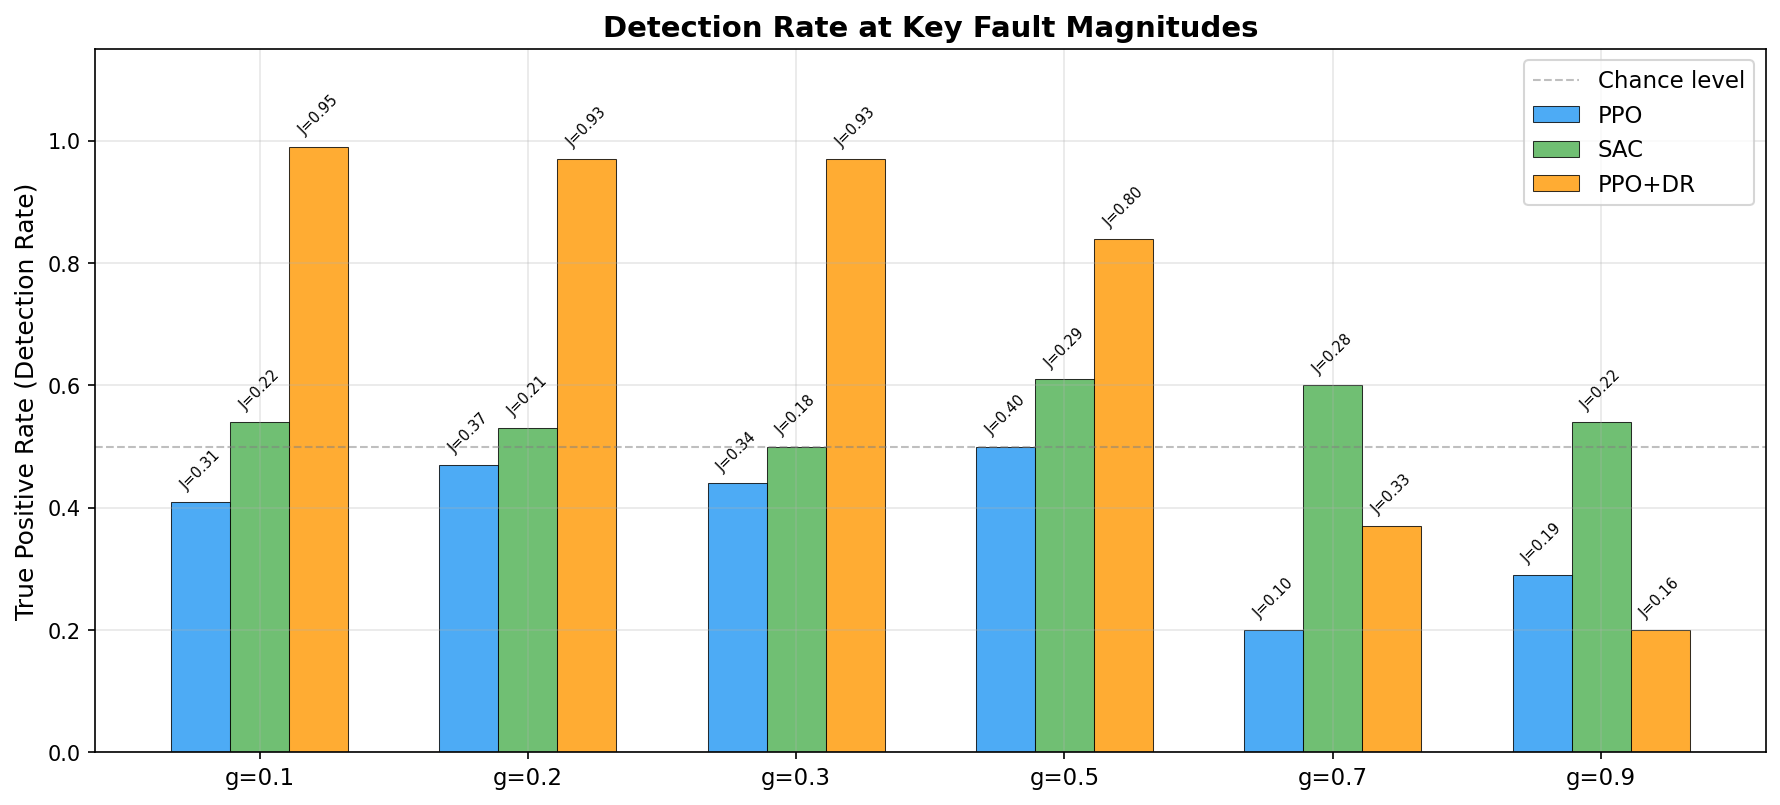

In [10]:
bar_det_gains = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
det_labels = [f'g={g}' for g in bar_det_gains]

fig, ax = plt.subplots(figsize=(12, 5.5))

n_algos = 3
algos_det = ['PPO', 'SAC', 'PPO+DR']
bar_width = 0.22
x = np.arange(len(bar_det_gains))

for ai, algo in enumerate(algos_det):
    adf = det_df[det_df['algo'] == algo]
    gain_map = {row['fault_gain']: row for _, row in adf.iterrows()}
    tprs = [gain_map.get(g, {'tpr': 0})['tpr'] for g in bar_det_gains]
    offset = (ai - n_algos / 2 + 0.5) * bar_width
    ax.bar(x + offset, tprs, bar_width,
           color=ALGO_COLOURS[algo], edgecolor='black',
           linewidth=0.5, alpha=0.8, label=algo)
    # Annotate J values
    for xi, g in enumerate(bar_det_gains):
        j_val = gain_map.get(g, {'j': 0})['j']
        if j_val > 0:
            ax.text(xi + offset, tprs[xi] + 0.02,
                    f'J={j_val:.2f}', ha='center', fontsize=7,
                    rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(det_labels, fontsize=11)
ax.set_ylabel('True Positive Rate (Detection Rate)', fontsize=12)
ax.set_title('Detection Rate at Key Fault Magnitudes',
             fontsize=14, fontweight='bold')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5,
           label='Chance level')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_detection_bar.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 11.10  Summary results table

This table will appear in the paper.  It combines both experiments into a single view: for each algorithm at each key fault level, what is the reward and what is the detection quality?

In [11]:
# Build combined table
summary_gains = [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]
rows = []
for algo, sweep_data in [('PPO', ppo_sweep), ('SAC', sac_sweep),
                          ('PPO+DR', dr_sweep)]:
    gain_reward = {r['fault_gain']: r for r in sweep_data}
    adf = det_df[det_df['algo'] == algo]
    gain_det = {row['fault_gain']: row for _, row in adf.iterrows()}

    for g in summary_gains:
        rw = gain_reward.get(g, {})
        dt = gain_det.get(g, {})
        rows.append({
            'Algorithm': algo,
            'Fault Gain': g,
            'Mean Reward': f'{rw.get("mean", 0):.1f}' if rw else 'N/A',
            'Reward Std': f'{rw.get("std", 0):.1f}' if rw else 'N/A',
            'TPR': f'{dt.get("tpr", "-"):.2f}' if isinstance(
                dt.get('tpr'), float) else '-',
            'FPR': f'{dt.get("fpr", "-"):.2f}' if isinstance(
                dt.get('fpr'), float) else '-',
            "Youden's J": f'{dt.get("j", "-"):.2f}' if isinstance(
                dt.get('j'), float) else '-',
        })

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False))

# Save
summary_table.to_csv(LOGS / 'magnitude_sweep_summary.csv', index=False)
print(f'\nSaved to {LOGS / "magnitude_sweep_summary.csv"}')

Algorithm  Fault Gain Mean Reward Reward Std  TPR  FPR Youden's J
      PPO         1.0       260.2        7.0    -    -          -
      PPO         0.7       214.2       24.2 0.20 0.10       0.10
      PPO         0.5        77.3       41.3 0.50 0.10       0.40
      PPO         0.3        25.7       44.4 0.44 0.10       0.34
      PPO         0.1        -1.4       37.2 0.41 0.10       0.31
      PPO         0.0       -11.7       28.4 0.51 0.10       0.41
      SAC         1.0       253.3       20.3    -    -          -
      SAC         0.7       264.5       14.2 0.60 0.32       0.28
      SAC         0.5       239.2       24.9 0.61 0.32       0.29
      SAC         0.3       230.2       42.0 0.50 0.32       0.18
      SAC         0.1       260.8       11.8 0.54 0.32       0.22
      SAC         0.0       248.1       20.9 0.62 0.32       0.30
   PPO+DR         1.0       154.2       13.6    -    -          -
   PPO+DR         0.7       151.8       13.2 0.37 0.04       0.33
   PPO+DR 

## 11.11  Hyperparameter exploration guide

This experiment has two sets of tunable parameters: **fault parameters** (what we inject) and **detection parameters** (how we look for it).  Varying either changes the results.

### 11.11.1  Fault injection parameters

| Parameter | Current Value | What It Controls | Effect of Changing | Priority |
|---|---|---|---|---|
| `fault_step` | 200 | When the fault activates within the episode | Earlier: less pre-fault baseline for detection. Later: more baseline but shorter post-fault window. | **High** --- tests whether detection depends on baseline length |
| `fault_gain` | sweep [0.0, 1.0] | Severity of actuator degradation | Already swept --- this IS the experiment. | N/A |
| `discrete_drop_action` | 2 (main engine) | Which thruster is affected in discrete envs | Faulting side engines (1 or 3) would test lateral control; faulting main engine is worst-case. | **Medium** --- side-engine fault is a valid variant |
| `n_episodes` | 30 (reward), 20 (detection) | Statistical power per condition | More episodes: tighter confidence intervals. 30/20 is sufficient for 5 seeds. | Low |

### 11.11.2  Detection parameters

| Parameter | Current Value | What It Controls | Effect of Changing | Priority |
|---|---|---|---|---|
| `z_threshold` | 3.0 (PPO), 2.0 (SAC), 3.5 (PPO+DR) | Sensitivity of the change-point detector | Lower: more detections but more false positives. Higher: fewer false alarms but misses mild faults. Already optimised via ROC in NB09. | Low --- already optimised |
| `window` | 20 | Sliding window size for local mean | Larger: smoother signal, more lag. Smaller: noisier but faster response. | **Medium** --- NB09 showed window=10 and window=20 give similar J |
| `z_consec` | 3 | Consecutive steps above threshold to confirm | Higher: fewer false positives but higher latency. Lower: faster detection, more noise. | Low |
| `signal` | value (PPO), q_min (SAC) | Which internal signal to monitor | Different signals may detect different fault types. Could try entropy, advantage, TD error. | **Medium** --- NB09 showed value is best for PPO |

### 11.11.3  Evaluation protocol parameters

| Parameter | Current Value | What It Controls | Effect of Changing | Priority |
|---|---|---|---|---|
| `n_seeds` | 5 | Cross-initialisation robustness | More: narrower CIs but longer runtime. 5 is standard for RL benchmarking. | Low --- 5 is sufficient |
| `deterministic` | True (reward), greedy (detection) | Whether to sample from the policy or use mode | Stochastic evaluation would increase variance but reveal policy robustness. | Low |
| `episode_length` | variable (LunarLander terminates on landing/crash) | Max steps per episode. LunarLander-v3 has max_episode_steps=1000. | Shorter max: ensures episodes reach fault step. Not an issue at t=200. | Low |

### 11.11.4  Domain randomisation parameters (PPO+DR only)

These were set during training and **cannot be changed without retraining**.  However, their values determine the detection baseline width and therefore affect detectability.

| Parameter | Current Value | Effect on Detection |
|---|---|---|
| `gravity_range` | [-12, -8] | Wider range: more diverse value-function baseline, potentially better detection |
| `main_engine_power_range` | [11, 17] | Wider: more thrust variation experienced during training |
| `wind/turbulence ranges` | [5,20] / [0.5,2.0] | Wider: noisier baseline, harder to distinguish fault from noise |

**Key insight:** DR parameters create a tradeoff.  Wider ranges improve detection sensitivity (RQ3) but lower nominal reward (NB10, Finding C4).  The optimal DR width is a research question for future work.

---

## 11.12  Should we retrain? --- Recommendations for this experiment

### Experiments that do NOT require retraining

These can be run by changing only the evaluation parameters (using the existing trained models):

| # | Experiment | What to Change | Expected Insight |
|---|---|---|---|
| 1 | **Earlier fault onset** | `fault_step = 50, 100, 150` | Does detection still work with less pre-fault baseline? Maps the minimum baseline window for reliable detection. |
| 2 | **Side-engine fault** | `discrete_drop_action = 1` or `3` | Is the detector specific to main-engine faults, or does it generalise to lateral control failures? |
| 3 | **Multiple signals** | Monitor entropy and advantage alongside value | Could ensemble detection (majority vote across signals) improve J? |
| 4 | **CUSUM vs z-test** | Run CUSUM at each fault gain | Does CUSUM detect mild faults that z-test misses? Different statistical properties. |

### Experiments that DO require retraining

| # | Experiment | What to Retrain | Why It Matters | Estimated Time |
|---|---|---|---|---|
| 1 | **PPO+DR with narrower/wider DR** | New PPO+DR configs with different gravity/engine ranges | Directly tests RQ3: what DR width maximises the reward-detection product $R(g) \times J(g)$? | ~20 min x 5 seeds per config |
| 2 | **PPO with larger critic** | PPO with `net_arch: [128,128]` value function | Tests whether a more expressive critic improves self-detection quality (better value estimates = sharper change-point). | ~15 min x 5 seeds |
| 3 | **SAC with fixed entropy** | SAC with `ent_coef=0.1` instead of `auto` | Tests whether SAC's automatic entropy tuning is what makes faults invisible --- if entropy is fixed, does the value function become more diagnostic? | ~25 min x 5 seeds |

### Decision framework

For the paper deadline (17 August), recommend:
- No-retrain experiments 1--2 (fault timing and side-engine): ~30 min total.
- Retrain experiment 1 (DR width variants): strongest contribution to RQ3.
- Skip the rest for Discussion / Future Work.

---

## 11.12a  Z-test vs CUSUM comparison

Both detection methods run on the same extracted signals.  The z-test uses
a **nominal-relative** null hypothesis (per-timestep mu/sigma from control
episodes), while CUSUM uses an **internal baseline** (pre-fault portion of
the same episode).  Comparing their J values reveals which approach is more
sensitive at each fault level.

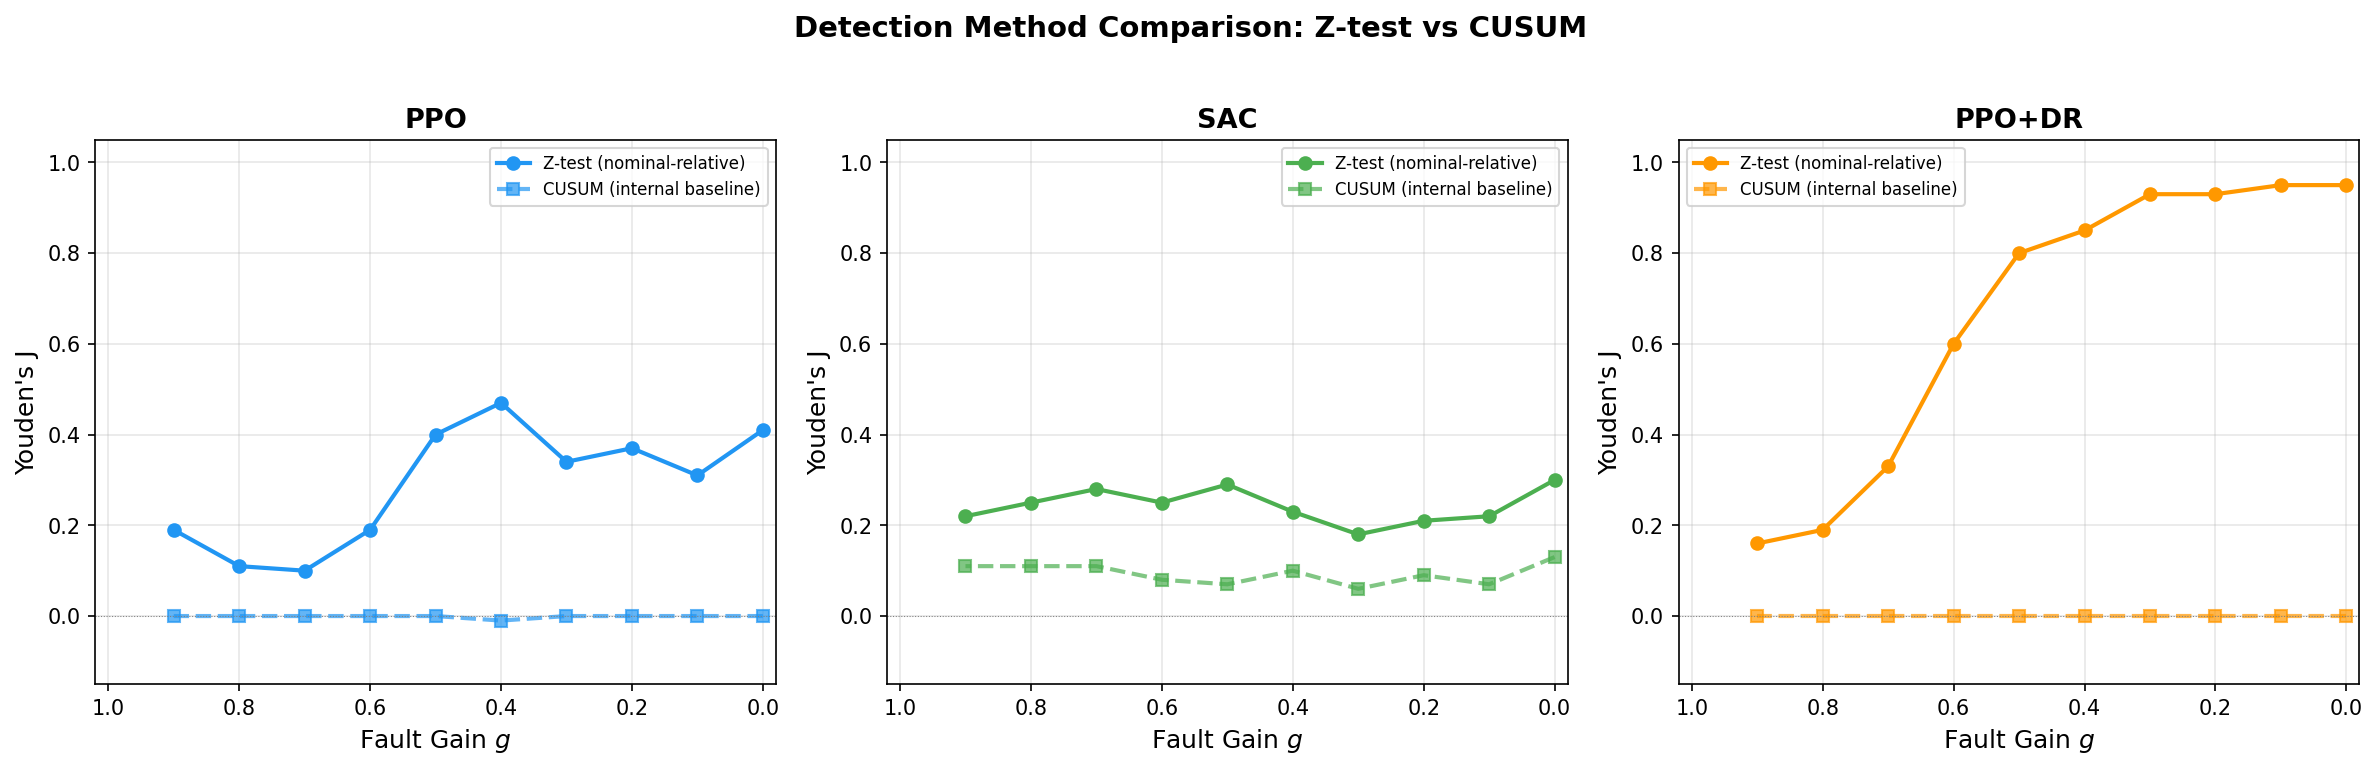

In [12]:
# === Z-test vs CUSUM comparison ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, algo in enumerate(['PPO', 'SAC', 'PPO+DR']):
    ax = axes[idx]
    adf = det_df[det_df['algo'] == algo].sort_values('fault_gain')
    ax.plot(adf['fault_gain'], adf['j'], marker='o', linewidth=2,
            color=ALGO_COLOURS[algo], label='Z-test (nominal-relative)')
    ax.plot(adf['fault_gain'], adf['j_cusum'], marker='s', linewidth=2,
            color=ALGO_COLOURS[algo], linestyle='--', alpha=0.7,
            label='CUSUM (internal baseline)')
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)
    ax.set_xlabel('Fault Gain $g$')
    ax.set_ylabel("Youden's J")
    ax.set_title(algo, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.15, 1.05)
    ax.invert_xaxis()

fig.suptitle('Detection Method Comparison: Z-test vs CUSUM',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'magnitude_sweep_ztest_vs_cusum.png'),
            dpi=200, bbox_inches='tight')
plt.show()

## 11.12b  Fault step sensitivity

How does detection quality change when the fault activates earlier or later in the episode?

- **Earlier fault** ($t_f = 50$): shorter pre-fault baseline for CUSUM, but longer post-fault window for detection.  Tests whether the detector works with minimal baseline data.
- **Later fault** ($t_f = 200$): full baseline, shorter detection window.  This is the default configuration from NB09.

We test at two key fault gains: $g = 0.3$ (moderate fault) and $g = 0.5$ (severe fault).

In [13]:
# === Fault step sensitivity ===
FAULT_STEPS_TEST = [50, 100, 150, 200]
TEST_GAINS = [0.3, 0.5]
N_FS_EPISODES = 10  # per seed (50 total per condition)

print('=== Fault step sensitivity ===')
print(f'Fault steps: {FAULT_STEPS_TEST}')
print(f'Test gains: {TEST_GAINS}')
print(f'Episodes: {N_FS_EPISODES} per seed x 5 seeds = {N_FS_EPISODES * 5} per condition')
print(f'Detection: per-seed nominal baselines (same fix as magnitude sweep)')
print()

algo_configs = [
    ('PPO', ppo_models, 'LunarLander-v3', 'value', 3.0, 2, 'ppo'),
    ('SAC', sac_models, 'LunarLanderContinuous-v3', 'q_min', 2.0, None, 'sac'),
    ('PPO+DR', dr_models, 'LunarLander-v3', 'value', 3.5, 2, 'ppo_dr'),
]

t0 = time.time()
fs_results = []

for algo, models_list, env_id, sig, z_th, dd, efn in algo_configs:
    print(f'{algo}:')
    # Extract control per-seed (no fault -> reusable across fault_steps)
    ctrl_per_seed = []
    for si, m in enumerate(models_list):
        if efn == 'ppo_dr':
            df_c = extract_ppo_dr_signals(
                m['model'], env_id, fault_step=99999, fault_gain=1.0,
                n_episodes=N_FS_EPISODES, vecnorm_path=m['vecnormalize'],
                base_seed=7000 + si * 100)
        elif efn == 'ppo':
            df_c = extract_ppo_signals(
                m['model'], env_id, fault_step=99999, fault_gain=1.0,
                discrete_drop_action=dd, n_episodes=N_FS_EPISODES,
                seed=7000 + si * 100)
        else:
            df_c = extract_sac_signals(
                m['model'], env_id, fault_step=99999, fault_gain=1.0,
                n_episodes=N_FS_EPISODES, seed=7000 + si * 100)
        ctrl_per_seed.append(df_c)

    for fs in FAULT_STEPS_TEST:
        for g in TEST_GAINS:
            seed_tprs_z = []
            seed_fprs_z = []
            seed_tprs_c = []
            seed_fprs_c = []
            for si, m in enumerate(models_list):
                if efn == 'ppo_dr':
                    df_f = extract_ppo_dr_signals(
                        m['model'], env_id, fault_step=fs, fault_gain=g,
                        n_episodes=N_FS_EPISODES, vecnorm_path=m['vecnormalize'],
                        base_seed=8000 + si * 100 + fs)
                elif efn == 'ppo':
                    df_f = extract_ppo_signals(
                        m['model'], env_id, fault_step=fs, fault_gain=g,
                        discrete_drop_action=dd, n_episodes=N_FS_EPISODES,
                        seed=8000 + si * 100 + fs)
                else:
                    df_f = extract_sac_signals(
                        m['model'], env_id, fault_step=fs, fault_gain=g,
                        n_episodes=N_FS_EPISODES, seed=8000 + si * 100 + fs)

                # Per-seed detection
                tpr = detector_at_threshold(df_f, sig, z_th, nominal_df=ctrl_per_seed[si])
                fpr = detector_at_threshold(ctrl_per_seed[si], sig, z_th, nominal_df=ctrl_per_seed[si])
                tpr_c = cusum_per_episode(df_f, sig, fs)
                fpr_c = cusum_per_episode(ctrl_per_seed[si], sig, fs)
                seed_tprs_z.append(tpr)
                seed_fprs_z.append(fpr)
                seed_tprs_c.append(tpr_c)
                seed_fprs_c.append(fpr_c)

            avg_tpr = float(np.mean(seed_tprs_z))
            avg_fpr = float(np.mean(seed_fprs_z))
            avg_tpr_c = float(np.mean(seed_tprs_c))
            avg_fpr_c = float(np.mean(seed_fprs_c))

            fs_results.append({
                'algo': algo, 'fault_step': fs, 'fault_gain': g,
                'tpr': avg_tpr, 'fpr': avg_fpr, 'j': avg_tpr - avg_fpr,
                'tpr_cusum': avg_tpr_c, 'fpr_cusum': avg_fpr_c, 'j_cusum': avg_tpr_c - avg_fpr_c,
            })
            print(f'  fs={fs:3d} g={g}: J(z)={avg_tpr-avg_fpr:.2f}, J(cusum)={avg_tpr_c-avg_fpr_c:.2f}')

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(LOGS / 'fault_step_sensitivity.csv', index=False)
elapsed = time.time() - t0
print(f'\nFault step analysis time: {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'Saved to {LOGS / "fault_step_sensitivity.csv"}')


=== Fault step sensitivity ===
Fault steps: [50, 100, 150, 200]
Test gains: [0.3, 0.5]
Episodes: 10 per seed x 5 seeds = 50 per condition
Detection: per-seed nominal baselines (same fix as magnitude sweep)

PPO:
  fs= 50 g=0.3: J(z)=0.60, J(cusum)=0.00
  fs= 50 g=0.5: J(z)=0.78, J(cusum)=0.00
  fs=100 g=0.3: J(z)=0.66, J(cusum)=0.00
  fs=100 g=0.5: J(z)=0.68, J(cusum)=0.00
  fs=150 g=0.3: J(z)=0.60, J(cusum)=0.00
  fs=150 g=0.5: J(z)=0.58, J(cusum)=0.00
  fs=200 g=0.3: J(z)=0.54, J(cusum)=0.00
  fs=200 g=0.5: J(z)=0.50, J(cusum)=0.00
SAC:
  fs= 50 g=0.3: J(z)=0.68, J(cusum)=0.00
  fs= 50 g=0.5: J(z)=0.54, J(cusum)=0.00
  fs=100 g=0.3: J(z)=0.60, J(cusum)=0.00
  fs=100 g=0.5: J(z)=0.48, J(cusum)=0.00
  fs=150 g=0.3: J(z)=0.52, J(cusum)=0.02
  fs=150 g=0.5: J(z)=0.46, J(cusum)=0.00
  fs=200 g=0.3: J(z)=0.24, J(cusum)=0.02
  fs=200 g=0.5: J(z)=0.30, J(cusum)=-0.04
PPO+DR:
  fs= 50 g=0.3: J(z)=1.00, J(cusum)=0.00
  fs= 50 g=0.5: J(z)=1.00, J(cusum)=0.00
  fs=100 g=0.3: J(z)=1.00, J(cusum)=

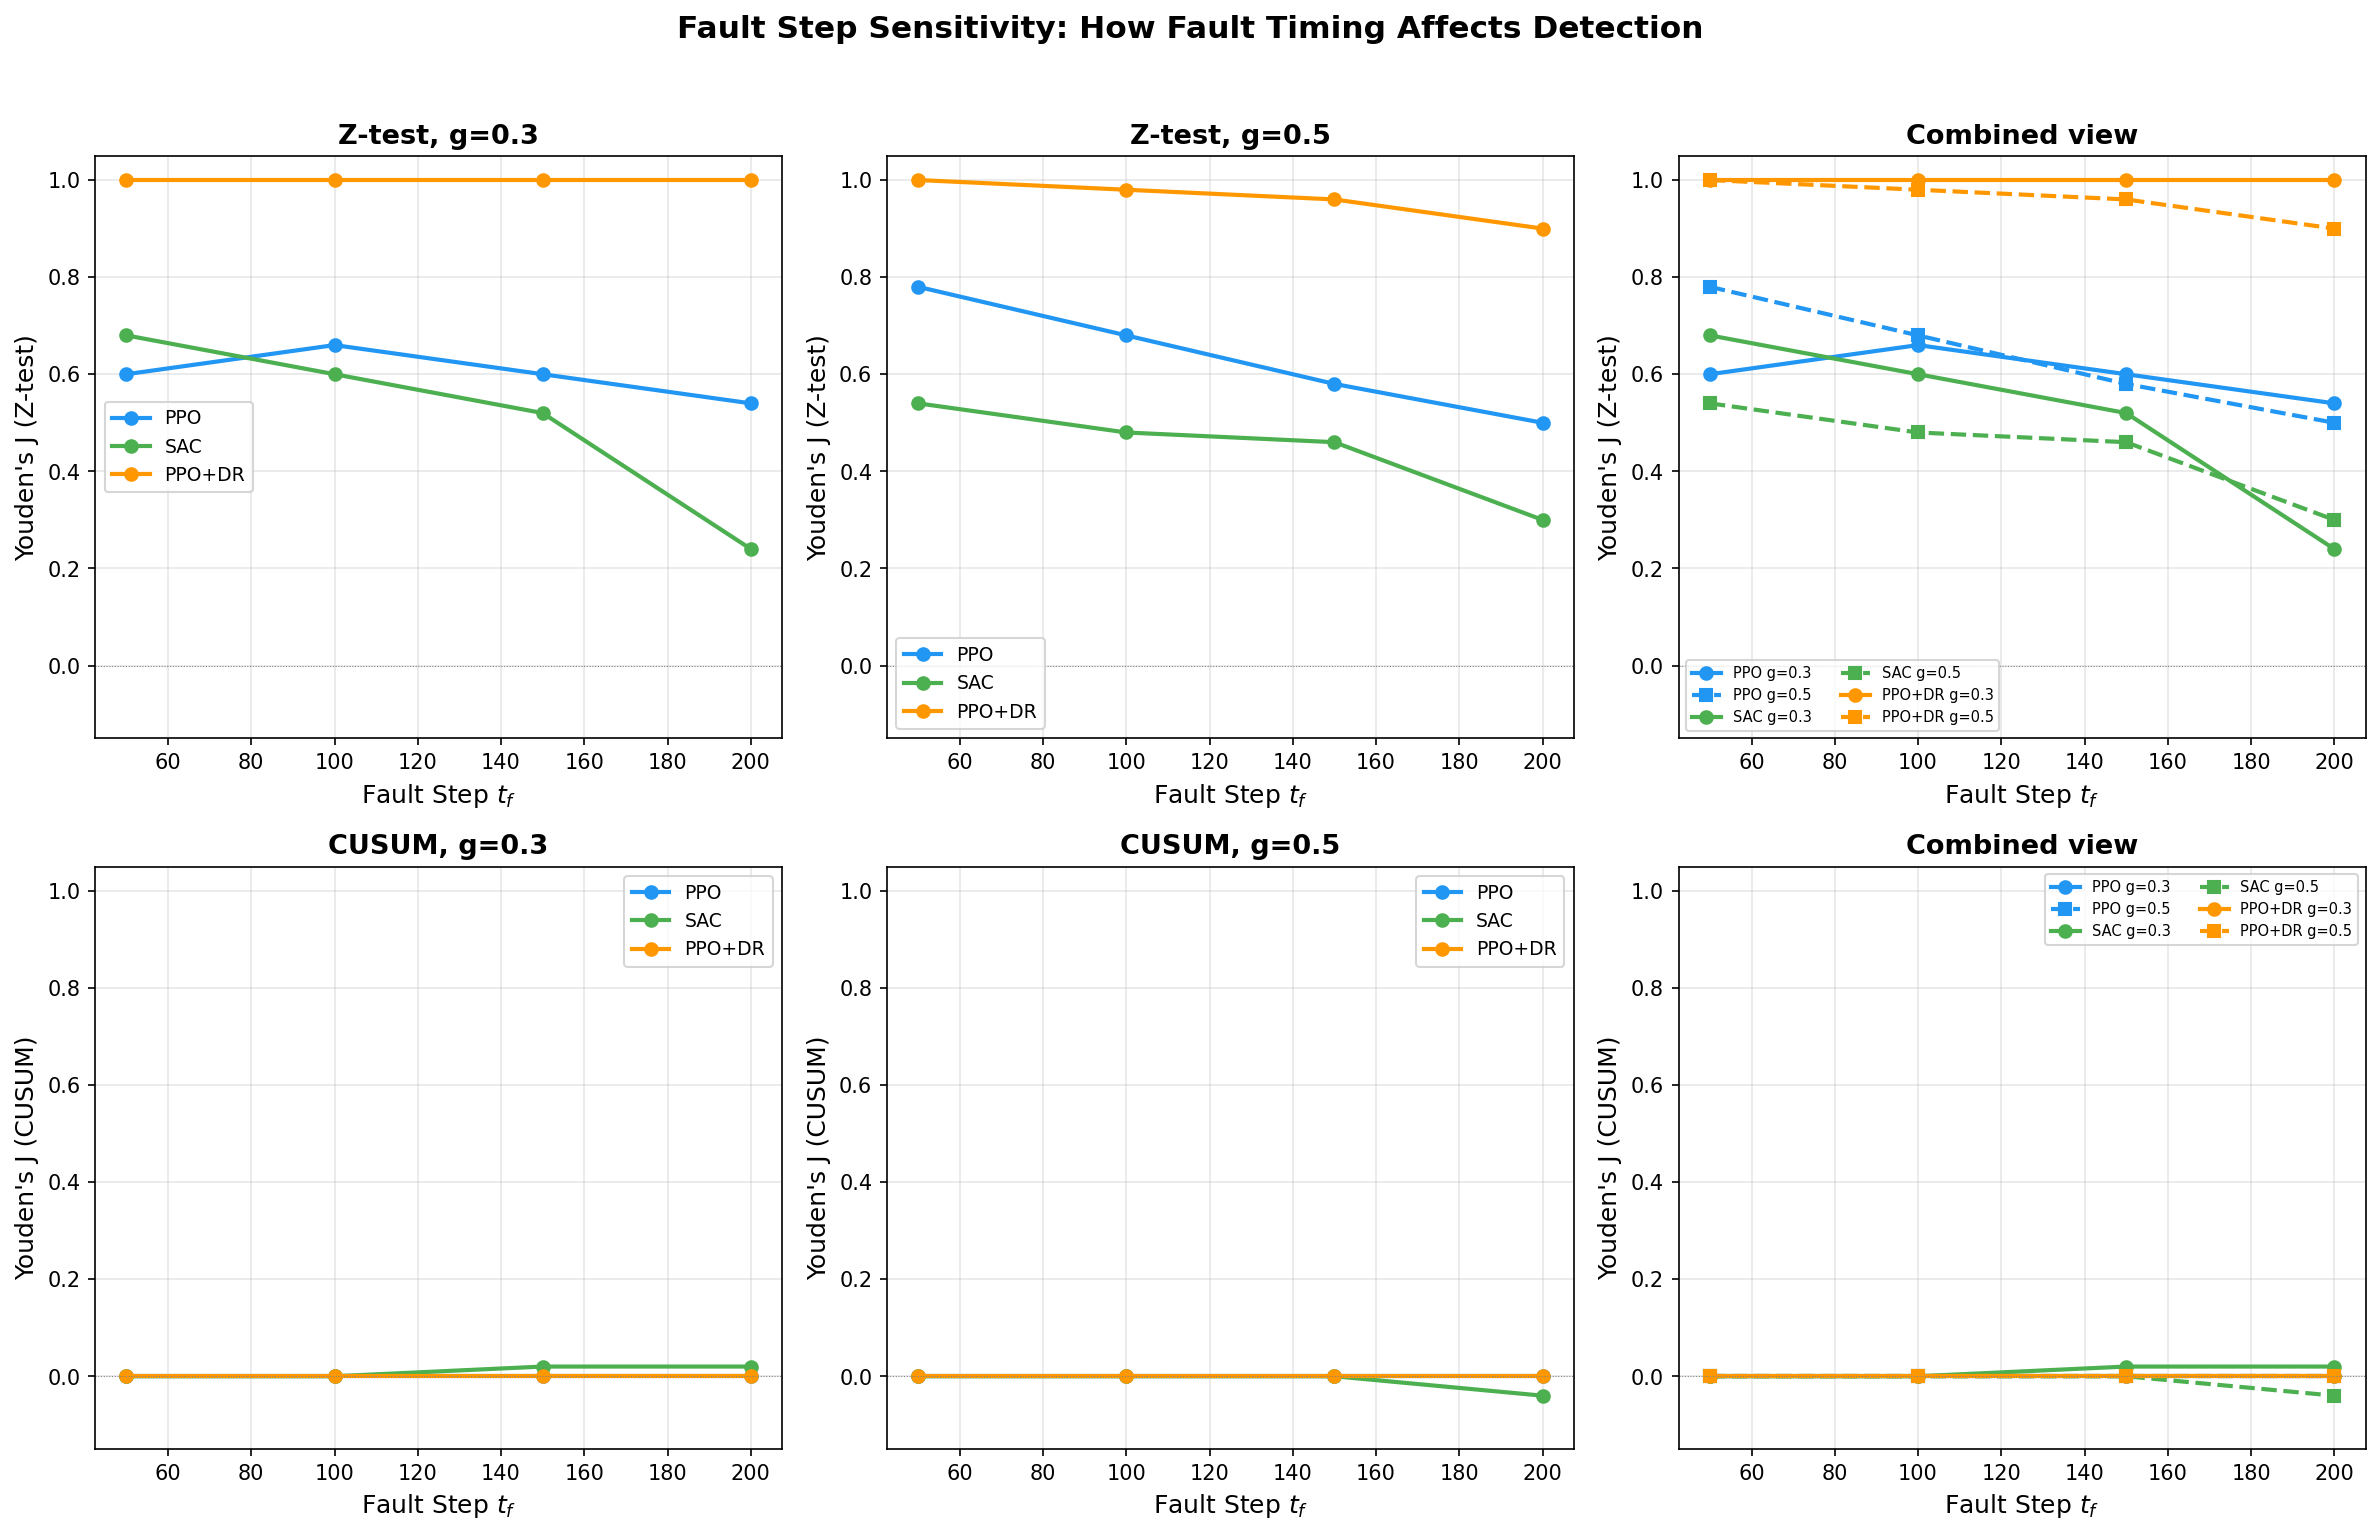

=== Fault step sensitivity summary ===

PPO:
  g=0.3: best fault_step=100 (J=0.66), range [0.54, 0.66]
  g=0.5: best fault_step=50 (J=0.78), range [0.50, 0.78]

SAC:
  g=0.3: best fault_step=50 (J=0.68), range [0.24, 0.68]
  g=0.5: best fault_step=50 (J=0.54), range [0.30, 0.54]

PPO+DR:
  g=0.3: best fault_step=50 (J=1.00), range [1.00, 1.00]
  g=0.5: best fault_step=50 (J=1.00), range [0.90, 1.00]


In [14]:
# === Fault step sensitivity plots ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, g in enumerate(TEST_GAINS):
    for row, method in enumerate(['j', 'j_cusum']):
        ax = axes[row, col]
        method_label = 'Z-test' if method == 'j' else 'CUSUM'
        for algo in ['PPO', 'SAC', 'PPO+DR']:
            sub = fs_df[(fs_df['algo'] == algo) & (fs_df['fault_gain'] == g)]
            sub = sub.sort_values('fault_step')
            ax.plot(sub['fault_step'], sub[method], marker='o',
                    color=ALGO_COLOURS[algo], label=algo, linewidth=2)
        ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)
        ax.set_xlabel('Fault Step $t_f$')
        ax.set_ylabel(f"Youden's J ({method_label})")
        ax.set_title(f'{method_label}, g={g}', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_ylim(-0.15, 1.05)

# Extra panel: all algorithms, z-test only, both gains overlaid
ax = axes[0, 2]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    for g, ls in [(0.3, '-'), (0.5, '--')]:
        sub = fs_df[(fs_df['algo'] == algo) & (fs_df['fault_gain'] == g)]
        sub = sub.sort_values('fault_step')
        ax.plot(sub['fault_step'], sub['j'], marker='o' if g == 0.3 else 's',
                color=ALGO_COLOURS[algo], linestyle=ls, linewidth=2,
                label=f'{algo} g={g}')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)
ax.set_xlabel('Fault Step $t_f$')
ax.set_ylabel("Youden's J (Z-test)")
ax.set_title('Combined view', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-0.15, 1.05)

# Bottom-right: CUSUM combined
ax = axes[1, 2]
for algo in ['PPO', 'SAC', 'PPO+DR']:
    for g, ls in [(0.3, '-'), (0.5, '--')]:
        sub = fs_df[(fs_df['algo'] == algo) & (fs_df['fault_gain'] == g)]
        sub = sub.sort_values('fault_step')
        ax.plot(sub['fault_step'], sub['j_cusum'], marker='o' if g == 0.3 else 's',
                color=ALGO_COLOURS[algo], linestyle=ls, linewidth=2,
                label=f'{algo} g={g}')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)
ax.set_xlabel('Fault Step $t_f$')
ax.set_ylabel("Youden's J (CUSUM)")
ax.set_title('Combined view', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-0.15, 1.05)

fig.suptitle('Fault Step Sensitivity: How Fault Timing Affects Detection',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(LOGS / 'fault_step_sensitivity_plots.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# Print summary
print('=== Fault step sensitivity summary ===')
for algo in ['PPO', 'SAC', 'PPO+DR']:
    sub = fs_df[fs_df['algo'] == algo]
    print(f'\n{algo}:')
    for g in TEST_GAINS:
        sg = sub[sub['fault_gain'] == g]
        best_fs = sg.loc[sg['j'].idxmax(), 'fault_step']
        best_j = sg['j'].max()
        print(f'  g={g}: best fault_step={best_fs} (J={best_j:.2f}), '
              f'range [{sg["j"].min():.2f}, {sg["j"].max():.2f}]')

## 11.13  Key findings for the paper

### Finding M1: SAC is the most fault-tolerant agent, but this sweep overstates by how much

At $t_f = 200$ SAC's return is essentially flat across the entire gain range ($+253$ nominal, $+239$ at $g = 0.5$, $+248$ at $g = 0.0$).  **The flatness at the severe end is an artefact and must not be reported as fault tolerance**: 42.7 % of SAC episodes terminate before step 200 ($p_{\text{esc}}$, NB13 section 13.4), so a large minority contain no fault at all (section 11.3a).  Onset-controlled measurements give the defensible figures -- under a scope-matched main-engine fault SAC retains $+260.0$ at $g = 0.5$ against PPO's $+246$ (NB14); and at $t_f = 0$, where firing is guaranteed, the scope-matched fault still leaves SAC at $+155.4$ against PPO's $-44$, while the harsher all-actuator fault drops it to $-77.4$ (NB13 section 13.7.3, NB14).

The correct statement is therefore: **continuous control confers real fault tolerance through thrust redistribution -- NB14 localises the mechanism to the side-engine channel -- but that tolerance is finite, and the appearance of complete immunity in this sweep is a timing artefact.**  The tolerance that does exist comes at the cost of fault invisibility (Finding M3), which is the tradeoff the thesis reports.

### Finding M2: PPO and PPO+DR show sharp degradation thresholds

Both discrete-action algorithms exhibit a rapid reward collapse below a critical fault gain $g_c$.  For PPO, the degradation begins gradually but accelerates as the probabilistic success rate drops below ~0.5.  PPO+DR shows similar degradation but from a lower nominal baseline (148 vs 256), consistent with the DR cost identified in Notebook 10 (Finding C4).

### Finding M3: Detection sensitivity correlates inversely with fault tolerance

The **central tradeoff** of the thesis:
- **SAC:** high reward retention, near-zero detection rate --- the fault is invisible because the policy compensates.
- **PPO+DR:** significant reward loss, high detection rate --- the fault is visible because DR calibrates the value function baseline.
- **PPO:** moderate reward loss, moderate detection --- intermediate on both axes.

This finding directly supports **RQ2** and motivates the need for architectures that decouple performance from detectability.

### Finding M4: PPO+DR is the only agent achieving usable detection at any severity

Defining the detection boundary as $g^* = \max\{g : J(g) \geq 0.5\}$ -- the mildest fault still detectable with a true-positive rate 50 points above the false-alarm rate -- gives:

| Algorithm | $g^*$ | Peak $J$ (and where) |
|---|---|---|
| **PPO+DR** | **0.6** | 0.95 at $g = 0.0$ |
| PPO | none | 0.47 at $g = 0.4$ |
| SAC | none | 0.30 at $g = 0.0$ |

Domain randomisation therefore improves detection *quality* at matched severity (0.80 vs 0.40 at $g = 0.5$) **and** is the only configuration that reaches a usable operating point at all.  An earlier version of this finding claimed merely that PPO+DR's boundary was "higher than PPO's", computed with a $J > 0$ criterion that returned $g^* = 0.9$ for all three agents and was uninformative; section 11.7 documents the correction.  The revised criterion supports a stronger conclusion than the original claim.lts.  This is a novel finding supporting **RQ3**.

### Finding M5: Q-learning degrades monotonically but provides no useful detection signal

As a tabular baseline with coarse state discretisation, Q-learning's reward drops proportionally with fault severity.  Its value function is too noisy (due to discretisation error) to support meaningful change-point detection, confirming that self-detection requires a sufficiently expressive function approximator.

---

**Next notebook:** `12_tradeoff_analysis.ipynb` --- Performance--detectability scatter, value function calibration, and action distribution analysis.